In [1]:
%load_ext autoreload
%autoreload 2

INITIAL_Q = 0.5

# Load Data

In [2]:
from spyglass.decoding.v1.waveform_features import UnitWaveformFeatures

# times_list, marks_list = (
#     UnitWaveformFeatures()
#     & {"features_param_name": "amplitude_probe"}
#     & "analysis_file_name LIKE 'wilbur20210404%'"
# ).fetch_data()

[2026-04-27 12:33:54,689][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


In [3]:
import os

os.chdir("/home/xulu/code/alison_spyglass")
from alison_behav import *


import datajoint as dj
from spyglass.utils.dj_helper_fn import fetch_nwb
from spyglass.common import AnalysisNwbfile

behavior_model_table = dj.FreeTable(
    dj.conn(), "`alison_rlmodel`.`__behavior_model_results__by_day`"
)

subject = "wilbur"
date = "20210404"
file_name = subject + date
nwb_file_name = file_name + "_.nwb"
behavior_model_params_name = "default_hmm"
behavior_model_params_name = "default_betalik_addleaf"
trials_info_by_rat_params_name = "decay_default"  # For some animals or sessions it could be 'decay_default2' where Alison reran the HMM
behav_results = behavior_model_table & {
    "nwb_file_name": nwb_file_name,
    "behavior_model_params_name": behavior_model_params_name,
    # "trials_info_by_rat_params_name": trials_info_by_rat_params_name,
}
# all_behav = behav_results.fetch1_dataframe()
all_behav = fetch_nwb(behav_results, (AnalysisNwbfile, "analysis_file_abs_path"))[0][
    "behavior_model_results_by_day"
]
all_behav

behav_results
script_table = StateScriptTrials() & {"nwb_file_name": nwb_file_name}
trials = []
epoch = []
t_poke = []
t_out = []
for epoch_i in script_table.fetch("epoch"):
    table = script_table & {"epoch": epoch_i}
    trials.extend(table.fetch1("trial"))
    epoch.extend([epoch_i] * len(table.fetch1("trial")))
    t_poke.extend(table.fetch1("poke_in_ts"))
    t_out.extend(table.fetch1("poke_out_ts"))
script_df = pd.DataFrame(
    {"epoch": epoch, "trial_number_by_epoch": trials, "t_poke": t_poke, "t_out": t_out},
)
script_df

##
trial_df = pd.merge(all_behav, script_df, on=["epoch", "trial_number_by_epoch"])
turn_lookup = {
    (1, 2): "right",
    (2, 1): "left",
    (3, 4): "right",
    (4, 3): "left",
    (5, 6): "right",
    (6, 5): "left",
}

fill_entries = [
    (1, "left", [3, 4, 5, 6]),
    (2, "right", [3, 4, 5, 6]),
    (3, "left", [1, 2, 5, 6]),
    (4, "right", [1, 2, 5, 6]),
    (5, "left", [1, 2, 3, 4]),
    (6, "right", [1, 2, 3, 4]),
]
for fill_entry in fill_entries:
    port, turn, other_ports = fill_entry
    for other_port in other_ports:
        turn_lookup[(port, other_port)] = turn

turns = []
for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    turns.append("start")
    for i in range(1, len(epoch_df)):
        turn = turn_lookup[(epoch_df["leaf"].values[i - 1], epoch_df["leaf"].values[i])]
        turns.append(turn)
if "turns" not in trial_df.columns:
    trial_df["turns"] = turns


prev_trial_reward = []
for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    prev_trial_reward.append(np.nan)
    prev_trial_reward.extend(epoch_df["reward"].values[:-1].tolist())
if "prev_trial_reward" not in trial_df.columns:
    trial_df["prev_trial_reward"] = prev_trial_reward

run_starts = []
for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    run_starts.append(np.nan)
    run_starts.extend(epoch_df["t_out"].values[:-1].tolist())
if "run_start" not in trial_df.columns:
    trial_df["run_start"] = run_starts


from spyglass.common import Nwbfile
from pynwb import NWBHDF5IO
from spyglass.utils.nwb_helper_fn import get_nwb_file
from spyglass.utils.dj_helper_fn import _get_nwb_object
from spyglass.common import DIOEvents, Nwbfile, interval_list_intersect
import numpy as np

file_path = Nwbfile().get_abs_path("wilbur20210404_.nwb")
nwb = get_nwb_file(file_path)
dio_query = (
    DIOEvents()
    & {"nwb_file_name": "wilbur20210404_.nwb"}
    & "dio_event_name LIKE 'pump%'"
)

pump_obj_ids = dio_query.fetch("dio_object_id")
all_pump_intervals = []
for obj_id in pump_obj_ids:
    obj = _get_nwb_object(nwb.objects, obj_id)
    state = obj.data[:]
    state_time = obj.timestamps[:]
    ind_on = np.where(state == 1)[0]
    pump_intervals = [
        [st, en] for st, en in zip(state_time[ind_on], state_time[ind_on + 1])
    ]
    all_pump_intervals.extend(pump_intervals)
all_pump_intervals = np.array(all_pump_intervals)
ind = np.argsort(all_pump_intervals[:, 0])
all_pump_intervals = all_pump_intervals[ind]

dio_query = (
    DIOEvents()
    & {"nwb_file_name": "wilbur20210404_.nwb"}
    & "dio_event_name LIKE 'poke%'"
)
poke_obj_ids = dio_query.fetch("dio_object_id")
all_poke_intervals = []
for obj_id in poke_obj_ids:
    obj = _get_nwb_object(nwb.objects, obj_id)
    state = obj.data[:]
    state_time = obj.timestamps[:]
    ind_on = np.where(state == 1)[0]
    poke_intervals = [
        [st, en] for st, en in zip(state_time[ind_on], state_time[ind_on + 1])
    ]
    all_poke_intervals.extend(poke_intervals)
all_poke_intervals = np.array(all_poke_intervals)
ind = np.argsort(all_poke_intervals[:, 0])
all_poke_intervals = all_poke_intervals[ind]

[12:34:07][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use table.fetch_nwb() method (logic integrated into FetchMixin) instead
[12:34:07][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that

In [4]:
import datajoint as dj

key = {"nwb_file_name": "Wilbur20210404_.nwb"}
schema = dj.schema("alison_decoding")

schema.list_tables()

table_name = "`alison_decoding`.`__clusterless_acausal_results_summary`"
acausal_results_table = dj.FreeTable(dj.conn(), table_name)

acausal_results_keys = (acausal_results_table & key).fetch("KEY")  # [0]
acausal_results = acausal_results_table & acausal_results_keys
nwb_list = fetch_nwb(acausal_results, (AnalysisNwbfile, "analysis_file_abs_path"))
decoding_df = pd.concat([nwb["results_df"] for nwb in nwb_list], ignore_index=True)
decoding_df.set_index("time", inplace=True)

[12:34:31][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use table.fetch_nwb() method (logic integrated into FetchMixin) instead
[12:34:31][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.mode

In [5]:
# out_path = "/stelmo/alison/big_df_pkls/"
# today_now = "20230113"
# subject_id = "wilbur"
# wilbur_big_df = pd.read_pickle(
#     out_path + subject_id + "_big_df_stabledecayNoRL_" + today_now + ".pkl"
# )
# alison_df = wilbur_big_df[wilbur_big_df["nwb_file_name"] == "wilbur20210404_.nwb"]
import pandas as pd

out_path = "/stelmo/sam/c3po_datasets/wilbur20210404_big_df.pkl"
alison_df = pd.read_pickle(out_path)

In [6]:
actual_segment = alison_df.actual_segment.values
seg_switch_points = np.where(actual_segment[:-1] != actual_segment[1:])[0] + 1
# print(len(seg_switch_points))
from_first_seg = alison_df.is_first_seg_of_trial.iloc[seg_switch_points - 1].values
first_choice_point_inds = seg_switch_points[from_first_seg]
first_choice_point_inds
choice_point_times = alison_df.index.values[first_choice_point_inds]
len(choice_point_times)

trial_t_choice = []
for st, en in zip(trial_df["run_start"], trial_df["t_poke"]):
    ind = np.where((choice_point_times >= st) & (choice_point_times <= en))[0]
    if len(ind) == 1:
        trial_t_choice.append(choice_point_times[ind[0]])
    elif len(ind) == 0:
        trial_t_choice.append(np.nan)
    else:
        raise ValueError("Multiple choice points found in a trial!")
len(trial_t_choice)

if "t_choice" not in trial_df.columns:
    trial_df["t_choice"] = trial_t_choice
# alison_df.columns
Q_array = trial_df[[f"Q{i}" for i in range(1, 7)]].values + INITIAL_Q
Q_trial = np.array(
    [Q_array[i, trial_df.leaf.values[i] - 1] for i in range(len(trial_df))]
)
Q_trial.shape
if "Q_trial" not in trial_df.columns:
    trial_df["Q_trial"] = Q_trial
Q_stem_array = trial_df[[f"Qstem{i}" for i in range(1, 4)]].values
stem_dict = {"A": 0, "B": 1, "C": 2}
trial_stem_index = np.array([stem_dict[s] for s in trial_df.stem.values])
Q_stem_trial = np.array(
    [Q_stem_array[i, trial_stem_index[i]] for i in range(len(trial_df))]
)
if not "Q_stem_trial" in trial_df.columns:
    trial_df["Q_stem_trial"] = Q_stem_trial
Q_stem_max = Q_stem_array.max(axis=1)
switch_val = Q_stem_max - Q_stem_trial
if not "switch_val" in trial_df.columns:
    trial_df["switch_val"] = switch_val

In [7]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": "wilbur20210404_.nwb"}
spikes_query = SortedSpikesGroup() & key

spikes_query
spikes_key = spikes_query.fetch1("KEY")
spikes = (spikes_query).fetch_spike_data(spikes_key)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

In [8]:
from spyglass.ripple.v1 import RippleTimesV1

ripple_key = {"nwb_file_name": "Wilbur20210404_.nwb"}
sleep_ripp_df = (
    RippleTimesV1() & ripple_key & "target_interval_list_name LIKE '%_s'"
).fetch_dataframe()
sleep_ripp_df = pd.concat(sleep_ripp_df)

run_ripp_df = (
    RippleTimesV1() & ripple_key & "target_interval_list_name LIKE '%_r%'"
).fetch_dataframe()
run_ripp_df = pd.concat(run_ripp_df)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core

In [ ]:
from spyglass.lfp.analysis.v1.lfp_band import LFPBandV1
from spyglass.lfp.lfp_merge import LFPOutput
from tqdm import tqdm

band_query = LFPBandV1() & key & "target_interval_list_name LIKE '%noPrePostTrialTimes'"
band_query = band_query & {"filter_name": "theta_5_11"}

lfp_query = LFPOutput.LFPV1() & {"lfp_electrode_group_name": "sb_single_mpfc"}
band_query = band_query & lfp_query.proj(lfp_merge_id="merge_id")

# band_query
band_intervals = band_query.fetch(
    "target_interval_list_name",
)
band_intervals.sort()

pfc_lfp = []
pfc_lfp_power = []
pfc_lfp_phase = []
for band_interval in tqdm(band_intervals):
    interval_key = {"target_interval_list_name": band_interval}
    band_query_interval = band_query & interval_key
    pfc_lfp.append(band_query_interval.fetch1_dataframe())
    pfc_lfp_power.append(band_query_interval.compute_signal_power())
    pfc_lfp_phase.append(band_query_interval.compute_signal_phase())

pfc_lfp = pd.concat(pfc_lfp)
pfc_lfp_power = pd.concat(pfc_lfp_power)
pfc_lfp_phase = pd.concat(pfc_lfp_phase)

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,interval_list_name descriptive name of this interval list,lfp_band_object_id the NWB object ID for loading this object from the file
2155a0eb-ab83-e532-7cb4-17eecda6890f,theta_5_11,1000,wilbur20210404_.nwb,02_r1 noPrePostTrialTimes,100,wilbur20210404_T4OLN4OQUT.nwb,02_r1 noPrePostTrialTimes lfp band 100Hz,7ac7bbc2-c6b4-4ca6-8606-979fe0230ffd
46d688b0-26c5-d28f-2193-d1dcc7e9a9b6,theta_5_11,1000,wilbur20210404_.nwb,06_r3 noPrePostTrialTimes,100,wilbur20210404_ZDOQBK0TD4.nwb,06_r3 noPrePostTrialTimes lfp band 100Hz,e392781c-6a94-41ba-a9b4-1bbe812c98f6
8b2cb398-b634-755b-1cb0-256dfc2cf297,theta_5_11,1000,wilbur20210404_.nwb,10_r5 noPrePostTrialTimes,100,wilbur20210404_8HKM36DQAY.nwb,10_r5 noPrePostTrialTimes lfp band 100Hz,f1d8ef9f-b7d8-4334-b298-a8f5f48f850a
a04571c5-32cc-a614-a979-2857b075bf97,theta_5_11,1000,wilbur20210404_.nwb,08_r4 noPrePostTrialTimes,100,wilbur20210404_4Q9CFTLVPO.nwb,08_r4 noPrePostTrialTimes lfp band 100Hz,dda0ab9c-b3f4-4fcb-ad1c-85dcb21d3f72
c4479a79-9792-cfac-21ec-f84c69cb3688,theta_5_11,1000,wilbur20210404_.nwb,04_r2 noPrePostTrialTimes,100,wilbur20210404_7F32LGSCVT.nwb,04_r2 noPrePostTrialTimes lfp band 100Hz,b606953c-e0ba-490e-bffd-3df7724fa035


In [90]:
pfc_lfp_phase

,electrode 128
time,
1.617554e+09,6.095825
1.617554e+09,0.693635
1.617554e+09,1.099121
1.617554e+09,1.570796
1.617554e+09,1.965929
...,...
1.617573e+09,2.840832
1.617573e+09,3.200192
1.617573e+09,3.562161


# Load Model

In [43]:
import os
import matplotlib.pyplot as plt

os.chdir("/home/sambray/Documents/c3po")
from src.c3po.tables.dev_tables import C3POStorage

# model_name = "rat_mpfc_model1_c20z20"
# model_name = "rat_mpfc_model202604_16dim_deep_trained"
# model_name = "rat_mpfc_model202604_20dim_runEpochs"
model_name = "rat_mpfc_model202604_20dim_runEpochs_smooth"
# model_name = "rat_mpfc_model202604_32dim_runEpochs_smooth"

model_key = {"model_name": model_name}
analysis = (C3POStorage & model_key).fetch_analysis_object()

analysis.load_embedding(
    f"/stelmo/sam/c3po_results/{model_key['model_name']}_embedding.npz"
)

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
# analysis.fit_context_pca()
# analysis.embed_context_pca()


# define figure directory
from src.c3po.analysis.analysis import figure_directory
from pathlib import Path

figure_directory = Path(figure_directory)
figure_folder = figure_directory / "Fig5" / model_name
os.makedirs(figure_folder, exist_ok=True)
plt.rcParams["svg.fonttype"] = "none"  # to get editable text in Illustrator

x shape (1, 33)


Could not load symbol cuFuncGetName. Error: /lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


In [44]:
from spyglass.common import TaskEpoch

run_query = (TaskEpoch() & {"nwb_file_name": "wilbur20210404_.nwb"}) - {
    "task_name": "sleep"
}
run_epoch_intervals = (IntervalList & run_query).fetch("valid_times")

run_epoch_intervals = np.concatenate(run_epoch_intervals, axis=0)
analysis.fit_context_pca(fit_intervals=run_epoch_intervals)
analysis.embed_context_pca()

In [32]:
port_intervals = trial_df[["t_poke", "t_out"]].values
port_intervals.shape

analysis_port = analysis.copy()
analysis_port.fit_context_pca(fit_intervals=port_intervals)
analysis_port.embed_context_pca()

In [ ]:
context_dim = analysis.context_dim
latent_dim = analysis.latent_dim

# Analyze!!

In [28]:
import matplotlib.pyplot as plt

### Example trial

(-20.0, 20.0)

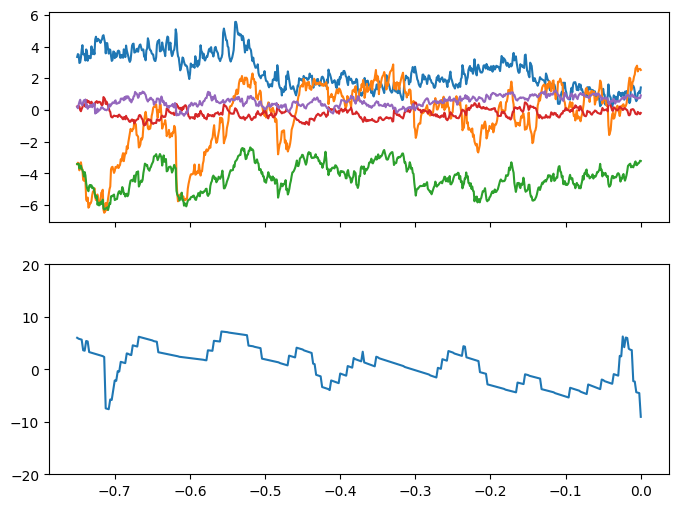

In [269]:
i = 350
marks = [trial_df["t_choice"].values[i]]
window = -0.75, 0.0


fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 6))
response = analysis.alligned_response(marks, window, pca=True)
t_plot = np.linspace(window[0], window[1], response.shape[1])
ax[0].plot(t_plot, response[0, :, :5])
t0 = marks[0]

ind = np.logical_and(
    decoding_df.index.values >= t0 + window[0],
    decoding_df.index.values <= t0 + window[1],
)
t_decode = decoding_df.index.values[ind] - t0
decoding_vals = decoding_df["ahead_behind_distance"].values[ind]
plt.plot(t_decode, decoding_vals)
ax[1].set_ylim(-20, 20)

# Ahead-behind values

In [270]:
valid_intervals = []
window = (-0.5, 0)
for t in trial_df["t_choice"].values[:]:
    valid_intervals.append([t + window[0], t + window[1]])

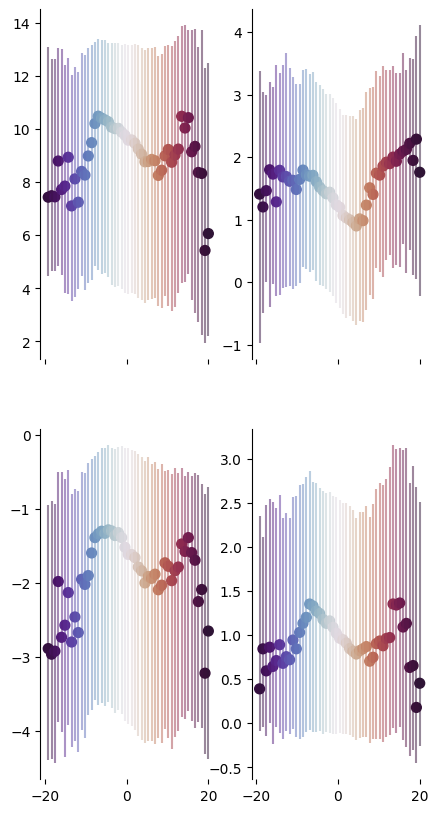

In [271]:
plotting = "median"
bins = np.linspace(-20, 20, 50)

binned_context, bins = analysis.bin_context_by_feature(
    decoding_df.ahead_behind_distance.values,
    decoding_df.index.values,
    pca=True,
    interpolated=True,
    valid_intervals=valid_intervals,
    bins=bins,
)

if plotting == "median":
    mid = [np.nanmedian(b, axis=0) for b in binned_context]
    hi = [
        np.nanpercentile(
            b,
            75,
            axis=0,
        )
        for b in binned_context
    ]
    lo = [
        np.nanpercentile(
            b,
            25,
            axis=0,
        )
        for b in binned_context
    ]
elif plotting == "mean":
    mid = [np.nanmean(b, axis=0) for b in binned_context]
    hi = [
        np.nanmean(b, axis=0) + np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
    lo = [
        np.nanmean(b, axis=0) - np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]

mid = np.array(mid)
lo = np.array(lo)
hi = np.array(hi)
fig, ax = plt.subplots(
    nrows=min(context_dim // 2, 10), ncols=2, figsize=(5, 10), sharex=True
)
c = [plt.cm.twilight_shifted(phase / (40) + 0.5) for phase in bins[1:]]
for i, a in enumerate(np.ravel(ax)):
    a.scatter(bins[1:], mid[:, i], s=50, c=c)
    a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, color=c)
    a.spines[["top", "right", "bottom"]].set_visible(False)
# ax[-1].spines["bottom"].set_visible(True)

# plt.xlabel("Theta Phase (radians)")
# plt.xticks(
#     np.linspace(0, 2 * np.pi, 5),
#     ["0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"],
# )
# ax[0].set_title(theta_key["filter_name"])

# ahead-behind + condition

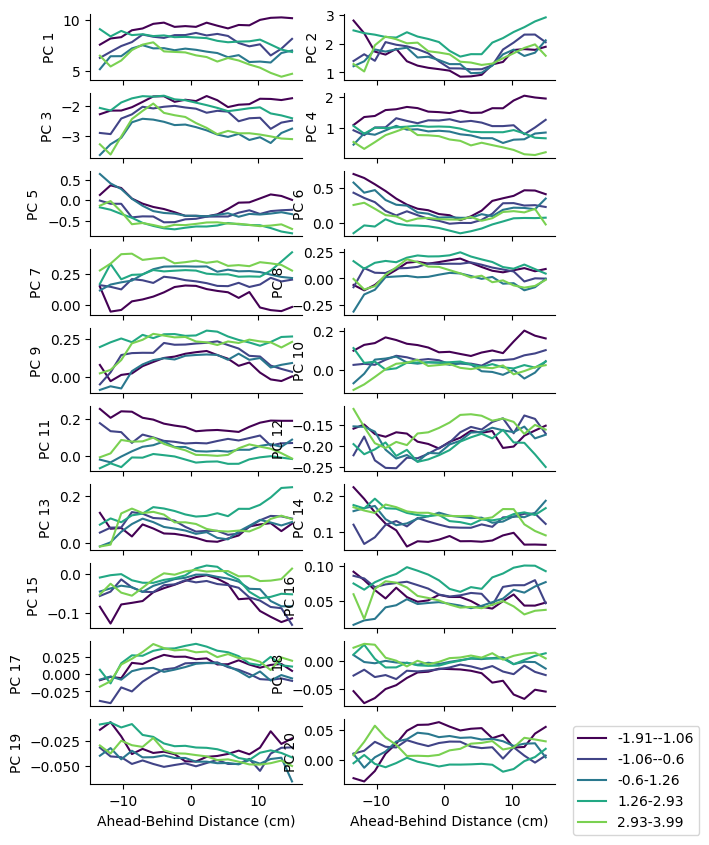

In [272]:
bins = np.linspace(-15, 15, 20)
max_marks = 500000

mark_feature = "t_choice"
window = (-0.5, 0)

# mark_feature= "run_start"
# window = (1,1.5)
# ------------------------

group_feature = "Q_trial"
feature_bins = np.linspace(0, 0.8, 10).round(2)
feature_bins = np.percentile(trial_df["Q_trial"].values, np.linspace(0, 100, 5)).round(
    2
)

group_feature = "Q_stem_trial"
feature_bins = np.linspace(0, 0.8, 8).round(2)
feature_bins = np.percentile(
    trial_df["Q_stem_trial"].values, np.linspace(10, 90, 6)
).round(2)

# ------------------------
exclude_feature = "n_pre_switch"
exclude_feature_values = [-1]


# ------------------------
if exclude_feature is None:
    exclude_mask = np.zeros(len(trial_df), dtype=bool)
else:
    val = trial_df[exclude_feature].values
    exclude_mask = np.isin(val, exclude_feature_values)

if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")
# ---


fig, ax_all = plt.subplots(
    min(10, analysis.context_dim // 2), ncols=2, figsize=(6, 10), sharex=True
)
ax = ax_all.flatten()

for i_cat, (inds, label) in enumerate(zip(category_inds, feature_labels)):
    if inds.sum() == 0:
        continue
    marks = trial_df[mark_feature].values[np.logical_and(inds, ~exclude_mask)]
    valid_intervals = []
    for t in marks[:max_marks]:
        valid_intervals.append([t + window[0], t + window[1]])

    binned_context, bins = analysis.bin_context_by_feature(
        decoding_df.ahead_behind_distance.values,
        decoding_df.index.values,
        pca=True,
        interpolated=True,
        valid_intervals=valid_intervals,
        bins=bins,
    )

    mid = [np.nanmean(b, axis=0) for b in binned_context]
    hi = [
        np.nanmean(b, axis=0) + np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
    lo = [
        np.nanmean(b, axis=0) - np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
    mid = np.array(mid)
    lo = np.array(lo)
    hi = np.array(hi)
    c = plt.cm.viridis(i_cat / len(feature_labels))
    for i, a in enumerate(np.ravel(ax)):
        a.plot(bins[1:], mid[:, i], c=c, label=label)
        # a.scatter(bins[1:], mid[:, i], s=50, c=c)
        # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, color=c)
        # a.spines[["top", "right", "bottom"]].set_visible(False)
        a.set_ylabel(f"PC {i+1}")

for a in ax:
    a.spines[
        [
            "top",
            "right",
        ]
    ].set_visible(False)
for a in ax_all[-1, :]:
    a.set_xlabel("Ahead-Behind Distance (cm)")
ax[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# Response grouped by condition

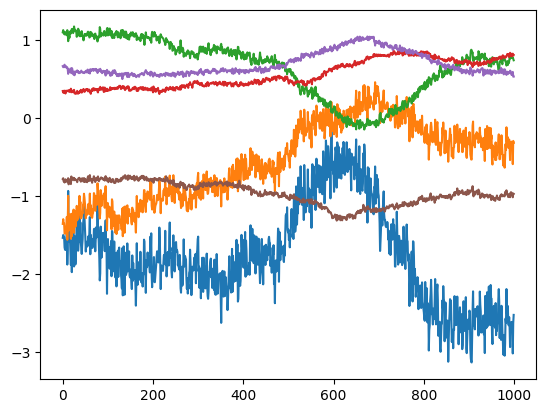

In [16]:
marks = trial_df[trial_df.reward == 1].t_out.values
marks = run_ripp_df.start_time
window = (-0.5, 0.5)

response = analysis.alligned_response(marks, window, pca=True)

plt.plot(response.mean(axis=0)[:, :6])

In [17]:
plt.hist?

Signature:
plt.hist(
    x: 'ArrayLike | Sequence[ArrayLike]',
    bins: 'int | Sequence[float] | str | None' = None,
    *,
    range: 'tuple[float, float] | None' = None,
    density: 'bool' = False,
    weights: 'ArrayLike | None' = None,
    cumulative: 'bool | float' = False,
    bottom: 'ArrayLike | float | None' = None,
    histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar',
    align: "Literal['left', 'mid', 'right']" = 'mid',
    orientation: "Literal['vertical', 'horizontal']" = 'vertical',
    rwidth: 'float | None' = None,
    log: 'bool' = False,
    color: 'ColorType | Sequence[ColorType] | None' = None,
    label: 'str | Sequence[str] | None' = None,
    stacked: 'bool' = False,
    data=None,
    **kwargs,
) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'
Docstring:
Compute and plot a histogram.

This method uses `numpy.histogram` to bin the data in *x* and count the
number of values in eac

(array([2.98724545, 0.03531023, 0.08474455, 0.12005478, 0.08474455,
        0.0918066 , 0.02824818, 0.05649637, 0.00706205, 0.02824818,
        0.02118614, 0.00706205, 0.02118614, 0.00706205, 0.00706205,
        0.        , 0.        , 0.        , 0.        , 0.00706205]),
 array([0.        , 0.27819651, 0.55639302, 0.83458953, 1.11278604,
        1.39098255, 1.66917906, 1.94737557, 2.22557208, 2.50376859,
        2.7819651 , 3.06016161, 3.33835812, 3.61655463, 3.89475114,
        4.17294765, 4.45114416, 4.72934067, 5.00753718, 5.28573369,
        5.5639302 ]),
 <BarContainer object of 20 artists>)

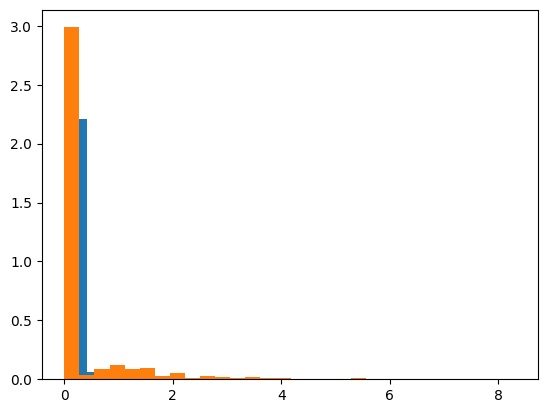

In [18]:
# _df = trial_df[trial_df.prev_trial_reward == 1]
# plt.hist(_df.stem_stay_p.values, bins=20)

_df = trial_df[trial_df.reward == 0]
plt.hist(_df.switch_val.values, bins=20, density=True)

_df = trial_df[trial_df.reward == 1]
plt.hist(_df.switch_val.values, bins=20, density=True)

In [75]:
[x for x in trial_df.columns if "switch" in x]

['stemswitch', 'n_post_switch', 'n_pre_switch']

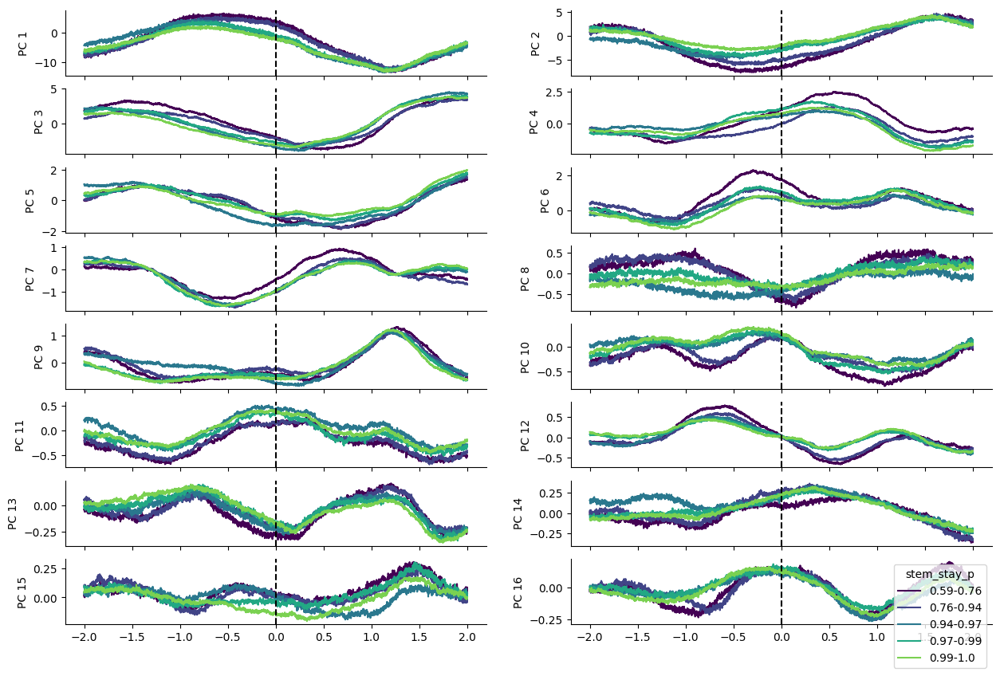

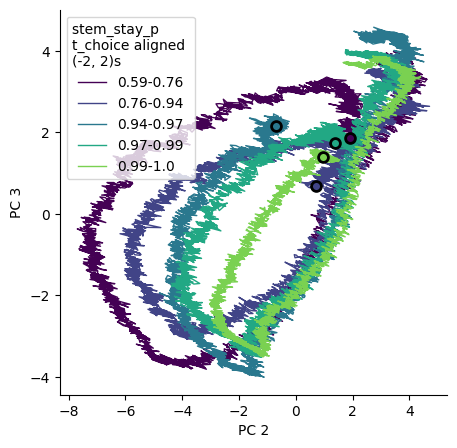

In [19]:
two_dim = [5, 6]
two_dim = [0, 1]
two_dim = [1, 2]

# -----------------------
mark_feature = "t_out"
window = (-2, 1)

# mark_feature = "t_poke"
# window = (-.5, 1.5)

# mark_feature = "run_start"
# window = (-0, 3)

mark_feature = "t_choice"
window = (-2, 2)

# -----------------------
group_feature = "reward"
feature_bins = None

group_feature = "prev_trial_reward"
feature_bins = None

group_feature = "stem_stay_p"
feature_bins = np.linspace(0, 1, 11).round(2)
feature_bins = np.percentile(
    trial_df[group_feature].values, np.linspace(10, 90, 6)
).round(2)

# group_feature = "stem_choice_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# exclude_labels = ["start"]

# group_feature = "Q_trial"
# feature_bins = np.linspace(0, 0.8, 10).round(2)
# feature_bins = np.percentile(trial_df["Q_trial"].values, np.linspace(0, 100, 5)).round(
#     2
# )

# group_feature = "Q_stem_trial"
# feature_bins = np.linspace(0, 0.8, 8).round(2)
# feature_bins = np.percentile(
#     trial_df["Q_stem_trial"].values, np.linspace(10, 90, 6)
# ).round(2)

# group_feature = "turns"
# feature_bins = None

# group_feature = "n_pre_switch"
# feature_bins = np.arange(5) + 0.1

# ------------------------
exclude_feature = "n_pre_switch"
exclude_feature_values = [0, -1]
exclude_labels = [None]

# exclude_feature = "reward"
# exclude_feature_values = [1]


# ------------------------
if exclude_feature is None:
    exclude_mask = np.zeros(len(trial_df), dtype=bool)
else:
    val = trial_df[exclude_feature].values
    exclude_mask = np.isin(val, exclude_feature_values)

if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")
# ---


fig, ax = plt.subplots(
    min(8, analysis.context_dim // 2), ncols=2, figsize=(15, 10), sharex=True
)
ax = ax.flatten()

fig_2d, ax_2d = plt.subplots(figsize=(5, 5))
for i_cat, (inds, label) in enumerate(zip(category_inds, feature_labels)):
    if inds.sum() == 0:
        continue
    marks = trial_df[mark_feature].values[np.logical_and(inds, ~exclude_mask)]

    response = analysis.alligned_response(marks, window, pca=True)
    mean_response = np.nanmean(response, axis=0)
    color = plt.cm.viridis(i_cat / len(category_inds))
    t_plot = np.linspace(
        window[0],
        window[1],
        mean_response.shape[0],
    )
    for i_dim, a in enumerate(ax):
        a.plot(t_plot, mean_response[:, i_dim], label=label, color=color)
        a.set_ylabel(f"PC {i_dim+1}")

    ax_2d.plot(
        mean_response[:, two_dim[0]],
        mean_response[:, two_dim[1]],
        label=label,
        color=color,
        lw=1,
        zorder=-1,
    )
    ax_2d.scatter(
        mean_response[0, two_dim[0]],
        mean_response[0, two_dim[1]],
        color=color,
        s=50,
        edgecolors="k",
        lw=2,
    )

for a in ax:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.axvline(0, color="k", linestyle="--")
ax[-1].legend(title=f"{group_feature}")

ax_2d.spines[["top", "right"]].set_visible(False)
ax_2d.set_xlabel(f"PC {two_dim[0]+1}")
ax_2d.set_ylabel(f"PC {two_dim[1]+1}")
ax_2d.legend(
    title=f"{group_feature} \n{mark_feature} aligned \n({window[0]}, {window[1]})s"
)

In [160]:
mean_response

nan

In [ ]:
fig.savefig(figure_folder / "avg_lick_response.svg")

In [ ]:
fig.savefig(
    figure_folder / f"mpfc_context_{group_feature}_by_{mark_feature}_aligned_PC.svg",
)
fig_2d.savefig(
    figure_folder
    / f"mpfc_context_{group_feature}_by_{mark_feature}_aligned_2D_PC{two_dim[0]+1}_{two_dim[1]+1}.svg",
)

# Two-factor grouping

In [64]:
trial_df.columns

Index(['nwb_file_name', 'epoch', 'trial_number_by_epoch', 'leaf', 'stem',
       'reward', 'contingency', 'date', 'session', 'rewscaled', 'stemchoice',
       'leafchoice', 'daynum', 'daysessionnum', 'stemswitch', 'n_post_switch',
       'n_pre_switch', 'cont_combo', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6',
       'Qstem1', 'Qstem2', 'Qstem3', 'Qleaf1', 'Qleaf2', 'state_entropy',
       'reward_entropy', 'reward_entropy_leaf_1', 'reward_entropy_leaf_2',
       'reward_entropy_leaf_3', 'reward_entropy_leaf_4',
       'reward_entropy_leaf_5', 'reward_entropy_leaf_6',
       'reward_entropy_current_leaf', 'reward_entropy_pair_prev_leaf',
       'reward_entropy_pair_current_leaf', 'stem_1_p', 'stem_2_p', 'stem_3_p',
       'stem_stay_p', 'stem_go_turn_p', 'stem_turn_alone_p', 'leaf_1_p',
       'leaf_2_p', 'stem_1_var', 'stem_2_var', 'stem_3_var', 'stem_stay_var',
       'stem_go_turn_var', 'stem_turn_alone_var', 'leaf_1_var', 'leaf_2_var',
       'stem_choice_p', 'leaf_choice_p', 'stem_choice_

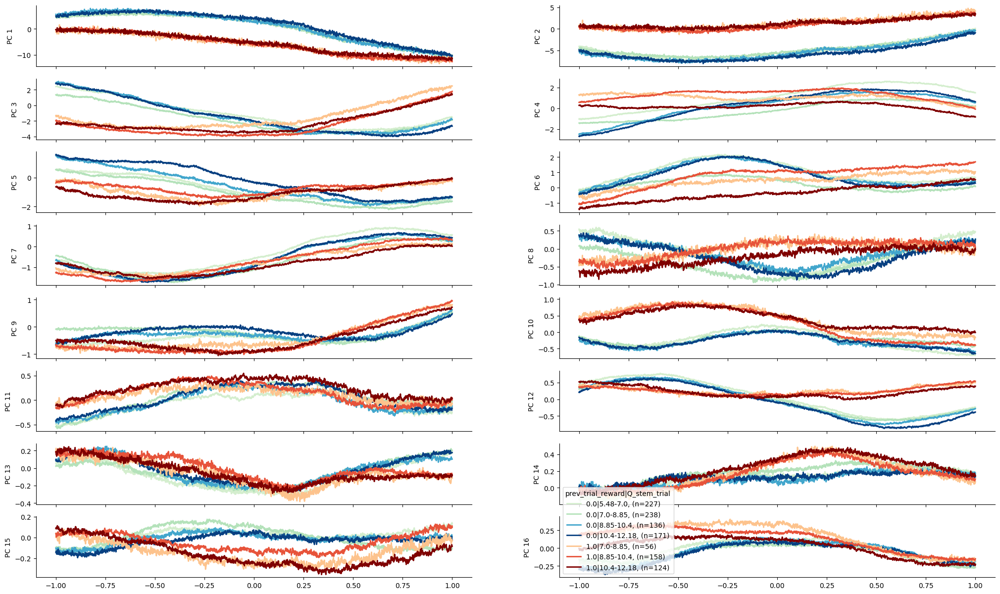

In [20]:
mark_feature = "t_out"
window = (-1, 1.5)


# mark_feature = "t_poke"
# window = (-1, 1)

# mark_feature = "run_start"
# window = (-0.25, 3)

mark_feature = "t_choice"
window = (-1, 1)

# -----------------------
# group_feature = "reward"
# feature_bins = None

# group_feature = "prev_trial_reward"
# feature_bins = None

# group_feature = "stem_choice_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# exclude_labels = ["start"]

group_feature = "Q_trial"
feature_bins = np.linspace(0, 0.5, 6).round(2)
feature_bins = np.array([0, 0.33, 1])
feature_bins = np.percentile(trial_df["Q_trial"].values, np.linspace(0, 100, 5)).round(
    2
)

group_feature = "Q_stem_trial"
feature_bins = np.linspace(0, 0.8, 8).round(2)
feature_bins = np.percentile(
    trial_df["Q_stem_trial"].values, np.linspace(10, 90, 5)
).round(2)

# group_feature = "stem_stay_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# feature_bins = np.percentile(
#     trial_df[group_feature].values, np.linspace(10, 90, 6)
# ).round(2)

exclude_labels_2 = []
exclude = None
# exc
# ----------------------
group_feature_2 = "reward"
feature_bins_2 = None


group_feature_2 = "prev_trial_reward"
feature_bins_2 = None
# exclude_labels_2 = []
# exclude_2 = None

# group_feature="turns"
# feature_bins=None

# group_feature = "n_pre_switch"
# feature_bins = np.arange(5) + 0.1

# ------------------------
exclude_feature = "n_pre_switch"
exclude_feature_values = [-1, 0]


# -------------------------
if exclude_feature is None:
    exclude_mask = np.zeros(len(trial_df), dtype=bool)
else:
    val = trial_df[exclude_feature].values
    exclude_mask = np.isin(val, exclude_feature_values)


if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        if exclude is not None:
            inds = np.logical_and(inds, feature_values != exclude)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")

if feature_bins_2 is None:
    feature_values_2 = trial_df[group_feature_2].values
    feature_labels_2 = np.unique(feature_values_2).tolist()
    feature_labels_2 = [
        label
        for label in feature_labels_2
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels_2 = [
        label for label in feature_labels_2 if label not in exclude_labels_2
    ]
    category_inds_2 = [feature_values_2 == val for val in feature_labels_2]
else:
    feature_values_2 = trial_df[group_feature_2].values
    category_inds_2 = []
    feature_labels_2 = []
    for lo, hi in zip(feature_bins_2[:-1], feature_bins_2[1:]):
        inds = (feature_values_2 >= lo) & (feature_values_2 <= hi)
        category_inds_2.append(inds)
        feature_labels_2.append(f"{lo}-{hi}")

# ---

fig, ax = plt.subplots(
    min(8, analysis.context_dim // 2), ncols=2, figsize=(25, 15), sharex=True
)
ax = ax.flatten()

cmaps = [plt.cm.GnBu, plt.cm.OrRd]


for i_cat_2, (inds_2, label_2) in enumerate(zip(category_inds_2, feature_labels_2)):
    if inds_2.sum() == 0:
        continue
    cmap = cmaps[i_cat_2]

    for i_cat, (inds, label) in enumerate(zip(category_inds, feature_labels)):
        if inds.sum() == 0:
            continue
        marks = trial_df[mark_feature].values[
            np.logical_and(np.logical_and(inds, inds_2), ~exclude_mask)
        ]
        marks = marks[~np.isnan(marks)]
        if len(marks) == 0:
            continue
        response = analysis.alligned_response(marks, window, pca=True)
        mean_response = np.nanmean(response, axis=0)
        c_val = i_cat / (len(category_inds) - 1)
        c_val = max(c_val, 0.2)
        color = cmap(c_val)
        t_plot = np.linspace(
            window[0],
            window[1],
            mean_response.shape[0],
        )
        plot_label = f"{label_2}|{label}, (n={marks.shape[0]})"
        for i_dim, a in enumerate(ax):
            a.plot(t_plot, mean_response[:, i_dim], label=plot_label, color=color, lw=2)
            a.set_ylabel(f"PC {i_dim+1}")

for a in ax:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
ax[-1].legend(title=f"{group_feature_2}|{group_feature}")

In [67]:
fig.savefig(
    figure_folder
    / f"two_feature_grouping_{group_feature}_and_{group_feature_2}_by_{mark_feature}_aligned_PC.svg",
)

# Learn value axis


In [226]:
mark_feature = "t_choice"
window = (-0.5, 0)

learned_feature = trial_df["Q_stem_trial"].values

marks = trial_df[mark_feature].values
alligned_response = analysis.alligned_response(marks, window, pca=True)

c_bar = np.mean(alligned_response, axis=1)
ind = np.logical_and(
    analysis.t[0] <= marks + window[0], analysis.t[-1] >= marks + window[1]
)
learned_feature = learned_feature[ind]
c_bar.shape, learned_feature.shape

((1495, 20), (1495,))

In [232]:
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(c_bar, learned_feature)
model.coef_

array([-0.1236303 , -0.09833489, -0.48827828, -0.64402133, -0.14709613,
       -1.66042568,  0.24847346,  0.55856359,  0.46579071, -1.20790234,
        0.22046401, -0.10126878,  1.40792255, -0.15614919, -0.78178389,
       -3.88168671,  4.28848393, -2.76599511, -4.8341276 ,  5.71101588])

In [233]:
analysis.add_projection("value", model.coef_)

In [234]:
analysis.projected_context

{'value': {'vector': array([-0.1236303 , -0.09833489, -0.48827828, -0.64402133, -0.14709613,
         -1.66042568,  0.24847346,  0.55856359,  0.46579071, -1.20790234,
          0.22046401, -0.10126878,  1.40792255, -0.15614919, -0.78178389,
         -3.88168671,  4.28848393, -2.76599511, -4.8341276 ,  5.71101588]),
  'from_pca': True,
  'data': array([[nan],
         [nan],
         [nan],
         ...,
         [nan],
         [nan],
         [nan]]),
  'data_interp': array([[nan],
         [nan],
         [nan],
         ...,
         [nan],
         [nan],
         [nan]])}}

Text(0.5, 1.0, 'Projection: value')

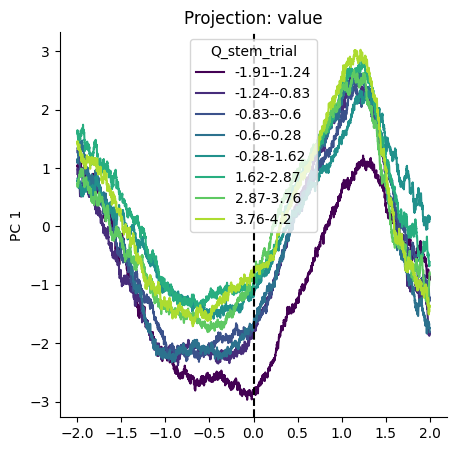

In [235]:
projection_name = "value"

# -----------------------
mark_feature = "t_out"
window = (-0.25, 1)

# mark_feature = "t_poke"
# window = (-0.5, 2)

# # mark_feature = "run_start"
# # window = (-0, 3)

mark_feature = "t_choice"
window = (-2, 2)

# -----------------------
group_feature = "reward"
feature_bins = None

# group_feature = "prev_trial_reward"
# feature_bins = None

# group_feature = "stem_choice_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# exclude_labels = ["start"]

# group_feature = "Q_trial"
# feature_bins = np.linspace(0, 0.8, 10).round(2)
# feature_bins = np.percentile(trial_df["Q_trial"].values, np.linspace(0, 100, 5)).round(
#     2
# )

group_feature = "Q_stem_trial"
feature_bins = np.linspace(0, 0.8, 8).round(2)
feature_bins = np.percentile(
    trial_df["Q_stem_trial"].values, np.linspace(10, 95, 9)
).round(2)

# group_feature = "turns"
# feature_bins = None

# group_feature = "n_pre_switch"
# feature_bins = np.arange(7) + 0.1

# ------------------------
exclude_feature = "n_pre_switch"
exclude_feature_values = [-1]


# ------------------------
if exclude_feature is None:
    exclude_mask = np.zeros(len(trial_df), dtype=bool)
else:
    val = trial_df[exclude_feature].values
    exclude_mask = np.isin(val, exclude_feature_values)

if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")
# ---


fig, ax = plt.subplots(figsize=(5, 5), sharex=True)
ax = [ax]
# ax = ax.flatten()

for i_cat, (inds, label) in enumerate(zip(category_inds, feature_labels)):
    if inds.sum() == 0:
        continue
    marks = trial_df[mark_feature].values[np.logical_and(inds, ~exclude_mask)]

    response = analysis.alligned_response(
        marks, window, pca=True, projection_name=projection_name
    )
    mean_response = np.nanmean(response, axis=0)
    color = plt.cm.viridis(i_cat / len(category_inds))
    t_plot = np.linspace(
        window[0],
        window[1],
        mean_response.shape[0],
    )
    for i_dim, a in enumerate(ax):
        a.plot(t_plot, mean_response[:, i_dim], label=label, color=color)
        a.set_ylabel(f"PC {i_dim+1}")

    # ax_2d.plot(
    #     mean_response[:, two_dim[0]],
    #     mean_response[:, two_dim[1]],
    #     label=label,
    #     color=color,
    # )

for a in ax:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.axvline(0, color="k", linestyle="--")
ax[-1].legend(title=group_feature)


plt.title(f"Projection: {projection_name}")

# ax_2d.spines[["top", "right"]].set_visible(False)
# ax_2d.set_xlabel(f"PC {two_dim[0]+1}")
# ax_2d.set_ylabel(f"PC {two_dim[1]+1}")
# ax_2d.legend(title=group_feature)

In [84]:
fig.savefig(
    figure_folder
    / f"manual_projection_{projection_name}_by_{group_feature}_alligned_to_{mark_feature}.svg",
)

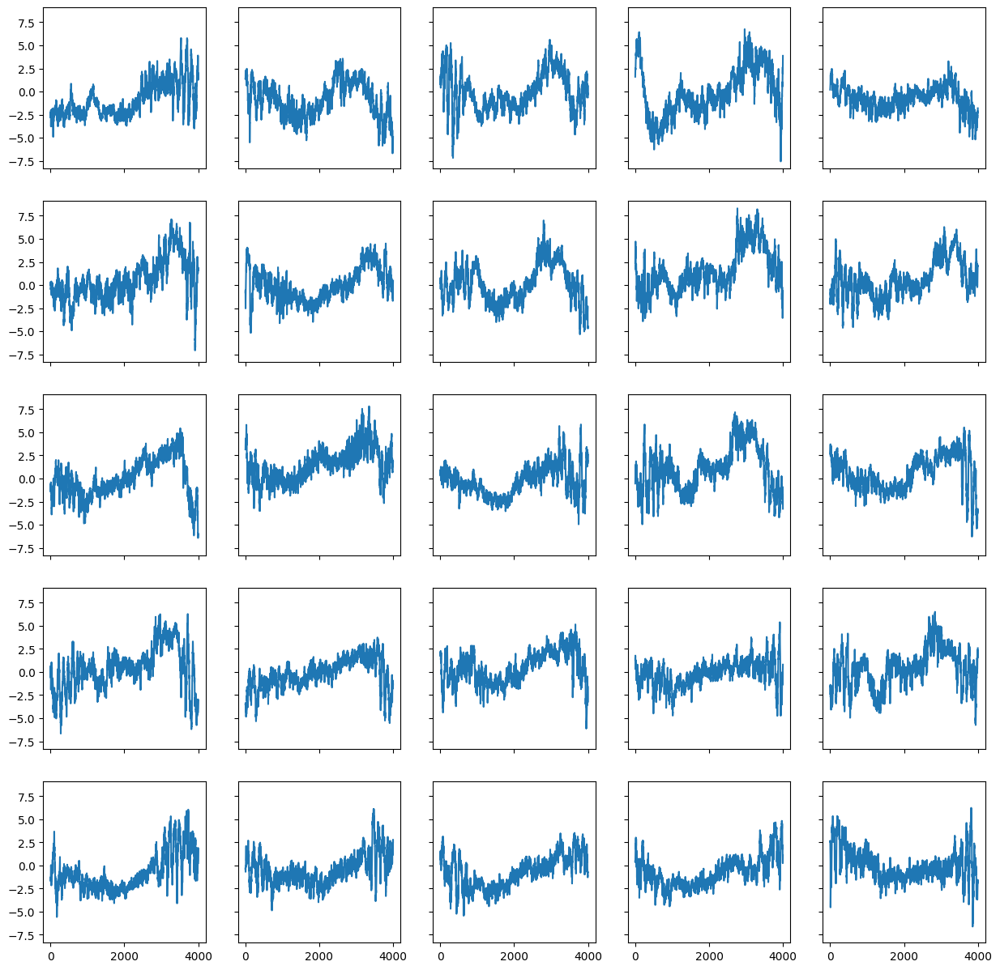

In [236]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True, figsize=(15, 15))
for i, a in enumerate(ax.flatten()):
    a.plot(response[i])

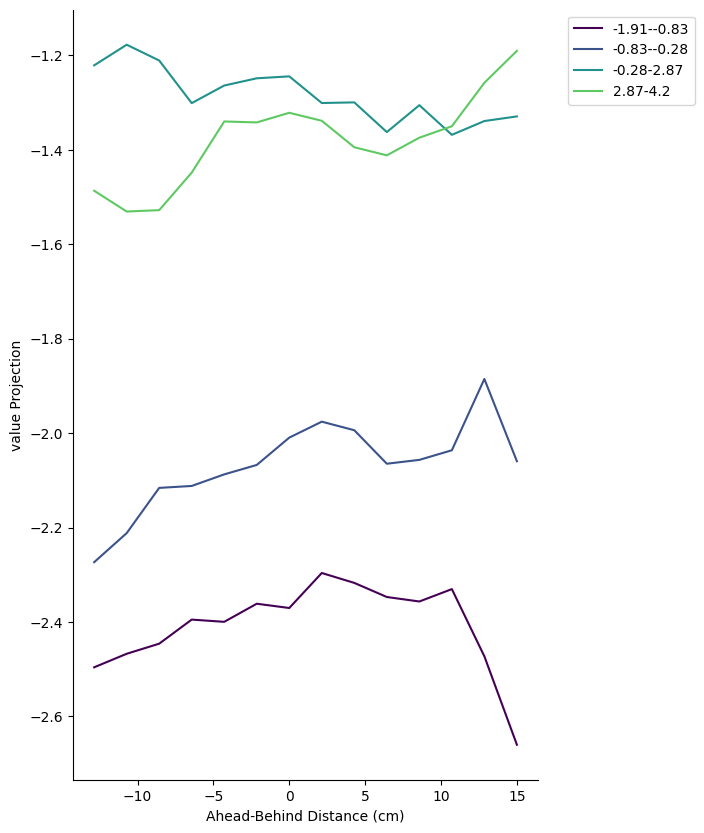

In [237]:
bins = np.linspace(-15, 15, 15)
shift_feature = 0.0
max_marks = 10000
projection_name = "value"

mark_feature = "t_choice"
window = (-1, 0)

# mark_feature = "t_out"
# window = (0, 1)

# mark_feature= "run_start"
# window = (1,1.5)
# ------------------------

group_feature = "Q_trial"
feature_bins = np.linspace(0, 0.8, 10).round(2)
feature_bins = np.percentile(trial_df["Q_trial"].values, np.linspace(0, 100, 5)).round(
    2
)

group_feature = "Q_stem_trial"
feature_bins = np.linspace(0, 0.8, 8).round(2)
feature_bins = np.percentile(
    trial_df["Q_stem_trial"].values, np.linspace(10, 95, 5)
).round(2)

# group_feature = "n_pre_switch"
# feature_bins = np.arange(5) + 0.1

# ------------------------
exclude_feature = "n_pre_switch"
exclude_feature_values = [-1]


# ------------------------
if exclude_feature is None:
    exclude_mask = np.zeros(len(trial_df), dtype=bool)
else:
    val = trial_df[exclude_feature].values
    exclude_mask = np.isin(val, exclude_feature_values)

if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")
# ---


fig, ax_all = plt.subplots(figsize=(6, 10), sharex=True)
ax = [ax_all]
# ax = ax_all.flatten()

all_binned_context = []

for i_cat, (inds, label) in enumerate(zip(category_inds, feature_labels)):
    if inds.sum() == 0:
        continue
    marks = trial_df[mark_feature].values[np.logical_and(inds, ~exclude_mask)]
    valid_intervals = []
    for t in marks[:max_marks]:
        valid_intervals.append([t + window[0], t + window[1]])

    binned_context, bins = analysis.bin_context_by_feature(
        decoding_df.ahead_behind_distance.values,
        decoding_df.index.values + shift_feature,
        pca=True,
        interpolated=True,
        valid_intervals=valid_intervals,
        bins=bins,
        projection_name=projection_name,
    )

    all_binned_context.append(binned_context.copy())

    mid = [np.nanmean(b, axis=0) for b in binned_context]
    hi = [
        np.nanmean(b, axis=0) + np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
    lo = [
        np.nanmean(b, axis=0) - np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
    mid = np.array(mid)
    lo = np.array(lo)
    hi = np.array(hi)
    c = plt.cm.viridis(i_cat / len(feature_labels))
    for i, a in enumerate(np.ravel(ax)):
        a.plot(bins[1:], mid[:, i], c=c, label=label)
        # a.scatter(bins[1:], mid[:, i], s=50, c=c)
        # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, color=c)
        # a.spines[["top", "right", "bottom"]].set_visible(False)
        a.set_ylabel(f"{projection_name} Projection")

for a in ax:
    a.spines[
        [
            "top",
            "right",
        ]
    ].set_visible(False)
    a.set_xlabel("Ahead-Behind Distance (cm)")
ax[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [ ]:
binned_context = all_binned_context[0]

bx = bins.copy()
by = np.linspace(-10, 10, 100)

density = np.zeros((len(bx) - 1, len(by) - 1))
centers = []
for i, vals in enumerate(binned_context):
    h, _ = np.histogram(vals[:, 0], bins=by)
    h = h / np.sum(h)
    density[i] = h
    centers.append(np.mean(vals, axis=0))

# density  = np.log10(density.T + 1e-5)

In [159]:
vals.shape

(1488, 1)

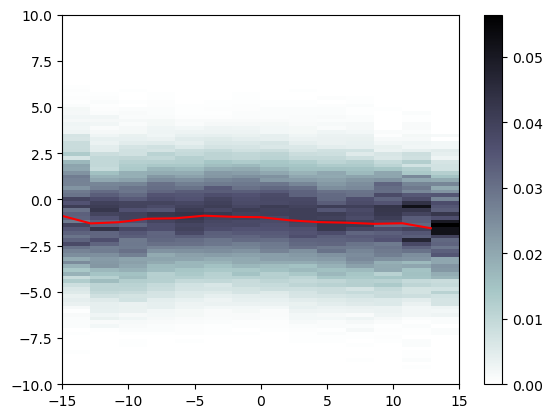

In [ ]:
plt.imshow(
    density.T,
    extent=(bx[0], bx[-1], by[0], by[-1]),
    aspect="auto",
    origin="lower",
    cmap="bone_r",
)
plt.plot(bins[:-1], [c[0] for c in centers], color="red")
plt.colorbar()

# PFC Theta LFP analysis

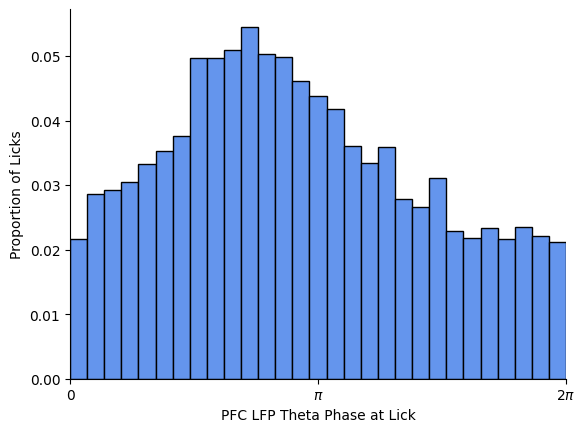

In [ ]:
licks = all_poke_intervals[:, 0]
ind = np.digitize(licks, pfc_lfp_phase.index.values) - 1
phase_at_lick = pfc_lfp_phase.iloc[ind].values

counts, bins = np.histogram(phase_at_lick, bins=np.linspace(0, 2 * np.pi, 30))

counts = counts / np.sum(counts)
# n_licks = len(all_poke_intervals)
# total_time_per_bin = n_licks * np.diff(bins)
# rate = counts / total_time_per_bin * 1000

plt.bar(
    bins[:-1],
    counts,
    width=np.diff(bins),
    align="edge",
    color="cornflowerblue",
    edgecolor="k",
)

plt.xlim(0, 2 * np.pi)
plt.xticks(
    [0, np.pi, 2 * np.pi],
    ["0", r"$\pi$", r"$2\pi$"],
)
plt.xlabel("PFC LFP Theta Phase at Lick")
plt.ylabel("Proportion of Licks")
plt.xlim(0, 2 * np.pi)
plt.gca().spines[["top", "right"]].set_visible(False)

Text(0, 0.5, 'PFC LFP Theta Phase')

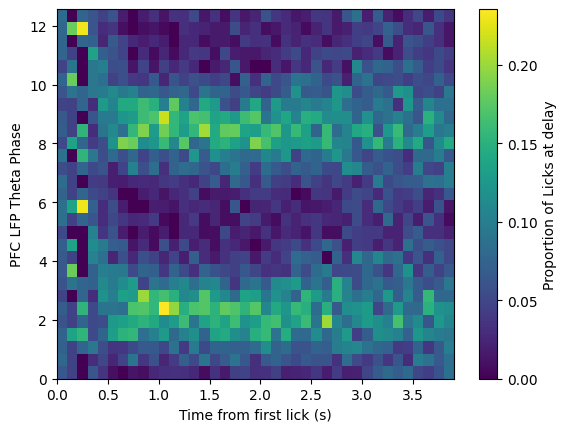

In [98]:
trial_ind = np.digitize(licks, trial_df.t_poke.values) - 1
rewarded_licks = trial_df.reward.values[trial_ind]

t_from_poke = licks - trial_df.t_poke.values[trial_ind]
t_from_poke.shape, phase_at_lick.shape

phase_bins = np.linspace(0, 4 * np.pi, 30)
time_bins = np.arange(0, 4, 0.1)
# time_bins = np.arange(0, 3, 0.1)

xx = t_from_poke
yy = phase_at_lick[:, 0]
xx = xx[rewarded_licks == 1]
yy = yy[rewarded_licks == 1]


xx = np.concatenate([xx, xx])
yy = np.concatenate([yy, yy + 2 * np.pi])

H, __, _ = np.histogram2d(xx, yy, bins=[time_bins, phase_bins])
H = H.T

H = H / np.sum(H, axis=0, keepdims=True) * 2
plt.imshow(
    H,
    extent=(time_bins[0], time_bins[-1], phase_bins[0], phase_bins[-1]),
    aspect="auto",
    origin="lower",
)
plt.colorbar(label="Proportion of Licks at delay")
plt.xlabel("Time from first lick (s)")
plt.ylabel("PFC LFP Theta Phase")

In [101]:
H.shape, H.sum(axis=0).shape

((29, 39), (39,))

In [ ]:
two_dim = [5, 6]
two_dim = [0, 1]
two_dim = [1, 2]

# -----------------------
mark_feature = "t_out"
window = (-2, 1)

# mark_feature = "t_poke"
# window = (-1, 2)

# mark_feature = "run_start"
# window = (-0, 3)

# mark_feature = "t_choice"
# window = (-2, 2)

# -----------------------
group_feature = "reward"
feature_bins = None

# group_feature = "prev_trial_reward"
# feature_bins = None

# group_feature = "stem_stay_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# feature_bins = np.percentile(
#     trial_df[group_feature].values, np.linspace(10, 90, 6)
# ).round(2)

# group_feature = "stem_choice_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# exclude_labels = ["start"]

# group_feature = "Q_trial"
# feature_bins = np.linspace(0, 0.8, 10).round(2)
# feature_bins = np.percentile(trial_df["Q_trial"].values, np.linspace(0, 100, 5)).round(
#     2
# )

# group_feature = "Q_stem_trial"
# feature_bins = np.linspace(0, 0.8, 8).round(2)
# feature_bins = np.percentile(
#     trial_df["Q_stem_trial"].values, np.linspace(10, 90, 6)
# ).round(2)

# group_feature = "turns"
# feature_bins = None

# group_feature = "n_pre_switch"
# feature_bins = np.arange(5) + 0.1

# ------------------------
exclude_feature = "n_pre_switch"
exclude_feature_values = [0, -1]
exclude_labels = [None]

# exclude_feature = "reward"
# exclude_feature_values = [1]


# ------------------------
if exclude_feature is None:
    exclude_mask = np.zeros(len(trial_df), dtype=bool)
else:
    val = trial_df[exclude_feature].values
    exclude_mask = np.isin(val, exclude_feature_values)

if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")
# ---


fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1)
ax = [ax]
# ax = ax.flatten()

fig_2d, ax_2d = plt.subplots(figsize=(5, 5))
for i_cat, (inds, label) in enumerate(zip(category_inds, feature_labels)):
    if inds.sum() == 0:
        continue
    marks = trial_df[mark_feature].values[np.logical_and(inds, ~exclude_mask)]

    response = analysis.alligned_response(
        marks,
        window,
        passed_data=(pfc_lfp_power.values, pfc_lfp_power.index.values),
    )
    mean_response = np.nanmean(response, axis=0)
    color = plt.cm.viridis(i_cat / len(category_inds))
    t_plot = np.linspace(
        window[0],
        window[1],
        mean_response.shape[0],
    )
    for i_dim, a in enumerate(ax):
        a.plot(t_plot, mean_response[:, i_dim], label=label, color=color)
        a.set_ylabel(f"PC {i_dim+1}")


for a in ax:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.axvline(0, color="k", linestyle="--")
ax[-1].legend(title=f"{group_feature}")

ax_2d.spines[["top", "right"]].set_visible(False)
ax_2d.set_xlabel(f"PC {two_dim[0]+1}")
ax_2d.set_ylabel(f"PC {two_dim[1]+1}")
ax_2d.legend(
    title=f"{group_feature} \n{mark_feature} aligned \n({window[0]}, {window[1]})s"
)

In [47]:
response.shape

(403, 200, 1)

# Theta-frequency power of context feature over time

In [53]:
band_results = dict()

In [ ]:
from spyglass.common import FirFilterParameters
import pandas as pd
from scipy.signal import hilbert

port_pcs = True

context_dim = analysis.context_dim
filter_name = "Theta 5-11 Hz"
# filter_name = "Fast Gamma 65-100 Hz"
if port_pcs:
    data = analysis_port.c_pca_interp[::1]
    t_data = analysis_port.t_interp[::1]
else:
    data = analysis.c_pca_interp[::1]
    t_data = analysis.t_interp[::1]
np.mean(np.diff(t_data))

filter_query = FirFilterParameters() & {
    "filter_sampling_rate": 1000,
    "filter_name": filter_name,
}
filter_ = (filter_query).fetch(as_dict=True)
filter_coeff = filter_[0]["filter_coeff"]

f = []
t_f = []
analytic_signal_df = []
power_df = []
phase_df = []

for interval in run_epoch_intervals:
    ind_st = np.searchsorted(t_data, interval[0], side="left")
    ind_end = np.searchsorted(t_data, interval[1], side="right")
    _f, _t_f = FirFilterParameters().filter_data(
        t_data[ind_st:ind_end],
        data[ind_st:ind_end],
        filter_coeff,
        [[t_data[ind_st], t_data[ind_end - 1]]],
        np.arange(context_dim),
        1,
    )
    f.extend(_f)
    t_f.extend(_t_f)

    _analytic_signal_df = pd.DataFrame(
        hilbert(_f, axis=0),
        index=pd.Index(_t_f, name="time"),
    )
    _phase_df = pd.DataFrame(
        np.angle(_analytic_signal_df) + np.pi,
        columns=_analytic_signal_df.columns,
        index=_analytic_signal_df.index,
    )
    _power_df = pd.DataFrame(
        np.abs(_analytic_signal_df) ** 2,
        columns=_analytic_signal_df.columns,
        index=_analytic_signal_df.index,
    )
    analytic_signal_df.append(_analytic_signal_df)
    phase_df.append(_phase_df)
    power_df.append(_power_df)

f = np.array(f)
t_f = np.array(t_f)

analytic_signal_df = pd.concat(analytic_signal_df)
phase_df = pd.concat(phase_df)
power_df = pd.concat(power_df)

ind = ~np.isnan(f).any(axis=1)
f = f[ind]
t_f = t_f[ind]

band_results[filter_name] = dict(
    signal=f,
    time=t_f,
    phase=phase_df,
    power=power_df,
)

In [ ]:
# import pandas as pd
# from scipy.signal import hilbert

# analytic_signal_df = pd.DataFrame(
#     hilbert(f, axis=0),
#     index=pd.Index(t_f, name="time"),
# )
# phase_df = pd.DataFrame(
#     np.angle(analytic_signal_df) + np.pi,
#     columns=analytic_signal_df.columns,
#     index=analytic_signal_df.index,
# )
# power_df = pd.DataFrame(
#     np.abs(analytic_signal_df) ** 2,
#     columns=analytic_signal_df.columns,
#     index=analytic_signal_df.index,
# )

# band_results[filter_name] = dict(
#     signal=f,
#     time=t_f,
#     phase=phase_df,
#     power=power_df,
# )

In [113]:
filter_name = "Theta 5-11 Hz"
filter_name = "Fast Gamma 65-100 Hz"
f = band_results[filter_name]["signal"]
t_f = band_results[filter_name]["time"]
phase_df = band_results[filter_name]["phase"]
power_df = band_results[filter_name]["power"]

Text(0.5, 0.98, 'Context Theta 5-11 Hz power, aligned to t_out')

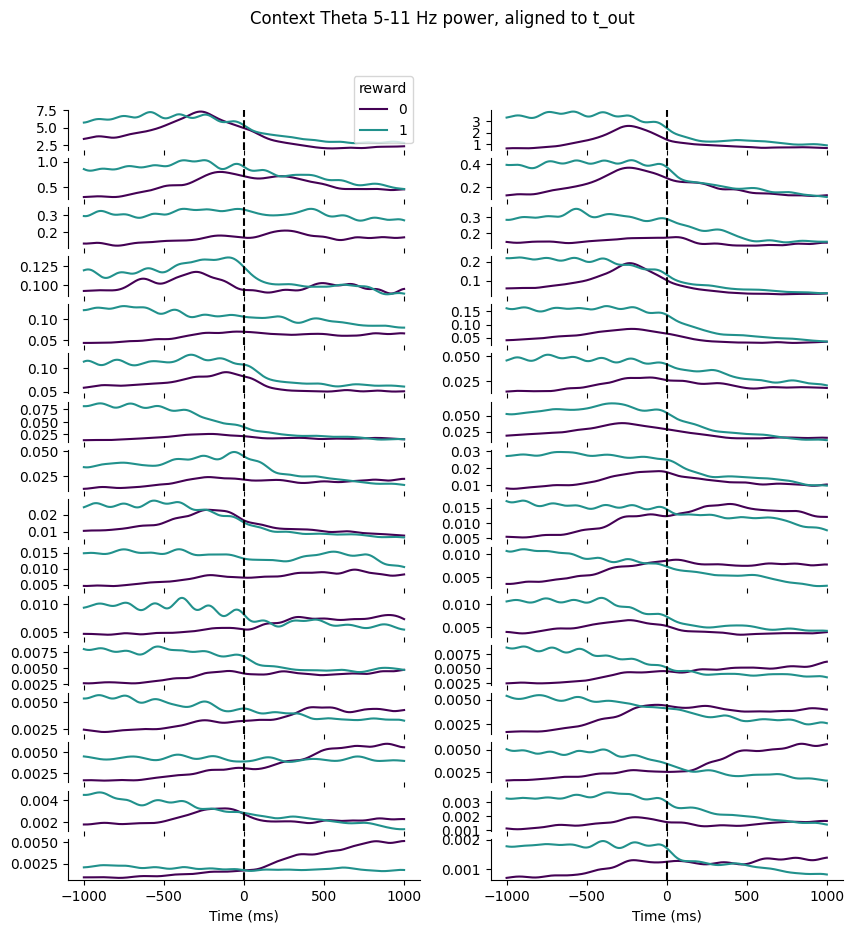

In [34]:
from src.c3po.analysis.analysis import bootstrap_traces

offset = 0
mark_feature = "t_poke"
window = (-0.5, 1)

offset = 0
mark_feature = "t_out"
window = (-1, 1)

# offset = 0
# mark_feature = "run_start"
# window = (-1, 1)

# offset = 0
# mark_feature = "t_choice"
# window = (-2, 2)


# ----------------------------------

group_feature = "n_pre_switch"
feature_bins = None
feature_bins = np.arange(5)

group_feature = "prev_trial_reward"
feature_bins = None

group_feature = "reward"
feature_bins = None

# group_feature = "turns"
# feature_bins = None


# group_feature = "Q_stem_trial"
# feature_bins = np.percentile(
#     trial_df[group_feature].values, np.linspace(10, 90, 6)
# ).round(2)

# group_feature = "Q_trial"
# feature_bins = np.percentile(
#     trial_df[group_feature].values, np.linspace(10, 90, 6)
# ).round(2)

exclude_labels = ["start"]
plot_examples = 0
#########################################################################
feature_ind = slice(None)

# marks_ind = slice(offset, None) if offset >= 0 else slice(None, offset)
# # feature_ind = slice(None, -offset) if offset > 0 else slice(-offset, None)
# marks = marks[marks_ind]

# marks = trial_df[mark_feature].values


# response = analysis.alligned_response(
#     marks,
#     window,
#     passed_data=(power_df.values, power_df.index),
# )
# t_plot = np.linspace(*window, response.shape[1]) * 1000


# ---------------------------------------------------------------------------'
# Single feature analysis
fig, ax = plt.subplots(nrows=context_dim // 2, ncols=2, sharex=True, figsize=(10, 10))
ax = np.ravel(ax)
subset_behav = all_behav.iloc[feature_ind]

# unique_vals = (
#     subset_behav[group_feature_name].unique() if feature_bins is None else feature_bins
# )

if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")


for i, (ind, val) in enumerate(zip(category_inds, feature_labels)):
    color = plt.cm.viridis(i / len(category_inds))
    # ind = trial_df[group_feature_name] == val
    marks = trial_df[mark_feature].values[ind]
    response = analysis.alligned_response(
        marks,
        window,
        passed_data=(power_df.values, power_df.index),
    )
    t_plot = np.linspace(*window, response.shape[1]) * 1000

    for i, a in enumerate(ax):
        data_i = response[..., i]
        # yy, rng = bootstrap_traces(data_i, n_boot=100)
        # a.fill_between(
        #     t_plot,
        #     *rng,
        #     alpha=0.3,
        #     facecolor=color,
        # )
        yy = data_i.mean(axis=0)
        a.plot(t_plot, yy, label=val, color=color)

        # a.plot(t_plot, data_i.mean(axis=0), label=val, color=color)
        a.spines[["top", "right", "bottom"]].set_visible(False)

for a in [ax[-1], ax[-2]]:
    a.set_xlabel("Time (ms)")
    a.spines["bottom"].set_visible(True)
for a in ax:
    a.axvline(0, color="k", linestyle="--")
ax[0].legend(title=group_feature)
fig.suptitle(f"Context {filter_name} power, aligned to {mark_feature}")

# plt.plot(t_plot, response.mean(axis=0))
# plt.xlim(-500,500)

In [25]:
# fig.savefig(
#     figure_folder
#     / f"power_of_context_{group_feature}_by_{mark_feature}_aligned_PC.svg",
# )

### power response to other features

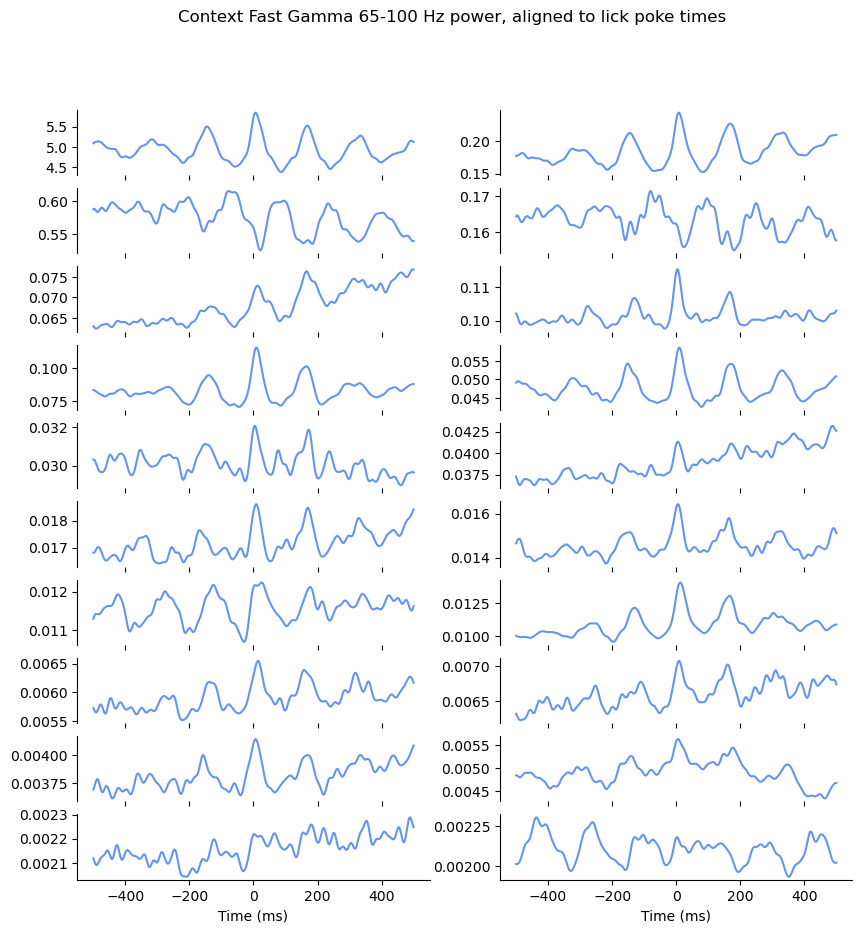

In [ ]:
# marks = run_ripp_df.stop_times.values
df = run_ripp_df[run_ripp_df.duration > 0.05]
marks = df.start_time.values
# new_marks = []
# for m in marks:
#     if np.min(np.abs(all_poke_intervals[:, 0] - m)) < 0.2:
#         new_marks.append(m)
# marks = np.array(new_marks)
mark_name = "ripple start times"


from spyglass.common import interval_list_contains

# rewarded_poke_times = interval_list_contains(reward_intervals, all_poke_intervals[:, 0])
marks = all_poke_intervals[:, 0]
mark_name = "lick poke times"


window = (-0.5, 0.5)


response = analysis.alligned_response(
    marks,
    window,
    passed_data=(power_df.values, power_df.index),
)
t_plot = np.linspace(*window, response.shape[1]) * 1000
fig, ax = plt.subplots(nrows=context_dim // 2, ncols=2, sharex=True, figsize=(10, 10))
ax = np.ravel(ax)
color = "cornflowerblue"
for i, a in enumerate(ax):
    data_i = response[..., i]
    # yy, rng = bootstrap_traces(data_i, n_boot=100)
    # a.fill_between(
    #     t_plot,
    #     *rng,
    #     alpha=0.3,
    #     facecolor=color,
    # )
    yy = data_i.mean(axis=0)
    a.plot(t_plot, yy, label=val, color=color)

    # a.plot(t_plot, data_i.mean(axis=0), label=val, color=color)
    a.spines[["top", "right", "bottom"]].set_visible(False)

    fig.suptitle(f"Context {filter_name} power, aligned to {mark_name}")

for a in ax[-2:]:
    a.set_xlabel("Time (ms)")
    a.spines["bottom"].set_visible(True)

### Aside: lick, ripple relationship

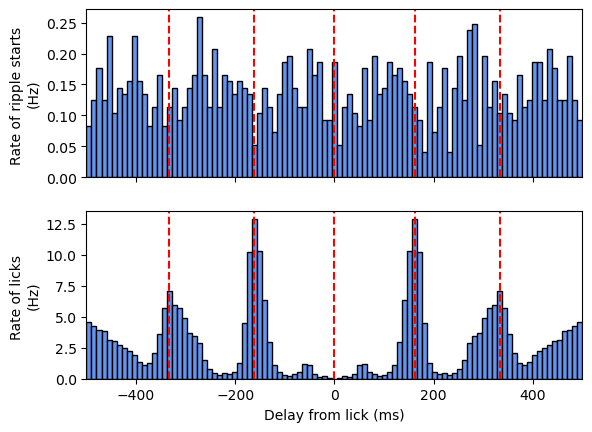

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True)

delays = np.subtract.outer(
    run_ripp_df.start_time.values,
    all_poke_intervals[:, 0],
)
delays = delays.flatten()
delays = delays[np.abs(delays) < 0.5] * 1000
# plt.hist(
#     delays,
#     bins=30,
# )

counts, bins = np.histogram(delays, bins=np.linspace(-500, 500, 100))

n_licks = len(all_poke_intervals)
total_time_per_bin = n_licks * np.diff(bins)
rate = counts / total_time_per_bin * 1000

ax[0].bar(
    bins[:-1],
    rate,
    width=np.diff(bins),
    align="edge",
    color="cornflowerblue",
    edgecolor="k",
)
# ax[0].set_title("Delays between lick times and ripple start times")
# ax[0].set_xlabel("Delayfrom lick (ms)")
ax[0].set_ylabel("Rate of ripple starts \n(Hz)")


delays = np.subtract.outer(
    all_poke_intervals[:, 0],
    all_poke_intervals[:, 0],
)
delays = delays.flatten()
delays = delays[np.abs(delays) < 0.5] * 1000
delays = delays[delays != 0]
# plt.hist(
#     delays,
#     bins=30,
# )

counts, bins = np.histogram(delays, bins=np.linspace(-500, 500, 100))

n_licks = len(all_poke_intervals)
total_time_per_bin = n_licks * np.diff(bins)
rate = counts / total_time_per_bin * 1000

ax[1].bar(
    bins[:-1],
    rate,
    width=np.diff(bins),
    align="edge",
    color="cornflowerblue",
    edgecolor="k",
)
# ax[1].set_title("Delays between lick times and ripple start times")
ax[1].set_xlabel("Delay from lick (ms)")
ax[1].set_ylabel("Rate of licks \n(Hz)")
ax[1].set_xlim(-500, 500)

ind_peaks = (
    np.where((rate[1:-1] > rate[:-2]) & (rate[1:-1] > rate[2:]) & (rate[1:-1] > 1))[0]
    + 1
)
peak_bins = bins[ind_peaks] + np.diff(bins[:2]) / 2
peak_bins = peak_bins[np.abs(peak_bins) > 100]
peak_bins = np.append(peak_bins, 0)
for pb in peak_bins:
    ax[0].axvline(pb, color="red", linestyle="--")
    ax[1].axvline(pb, color="red", linestyle="--")

# plt.xlim(-50,200)

In [238]:
nwb_file_name

'wilbur20210404_.nwb'

### Phase power nesting

In [ ]:
phase_filter_name = "Theta 5-11 Hz"
power_filter_name = "Fast Gamma 65-100 Hz"
phase_pc = 0

analyze_intervals = []
df = trial_df[trial_df.reward == 1]

for t_poke, t_out in zip(df.t_poke.values, df.t_out.values):
    analyze_intervals.append([t_poke, t_out])

In [ ]:
plotting = "mean"
phase_bins = np.linspace(0, 2 * np.pi, 50)

shift_phase = np.pi
phase_val = band_results[phase_filter_name]["phase"][phase_pc].values

if shift_phase:
    phase_val = (phase_val + shift_phase) % (2 * np.pi)

binned_context, bins = analysis.bin_context_by_feature(
    phase_val,
    band_results[phase_filter_name]["phase"].index,
    # pca=True,
    # interpolated=True,
    alt_data=(
        band_results[power_filter_name]["power"].index.values,
        band_results[power_filter_name]["power"].values,
    ),
    # alt_data=(
    #     band_results[power_filter_name]["time"],
    #     band_results[power_filter_name]["signal"],
    # ),
    bins=phase_bins,
    valid_intervals=analyze_intervals,
)

(2.0, 5.0)

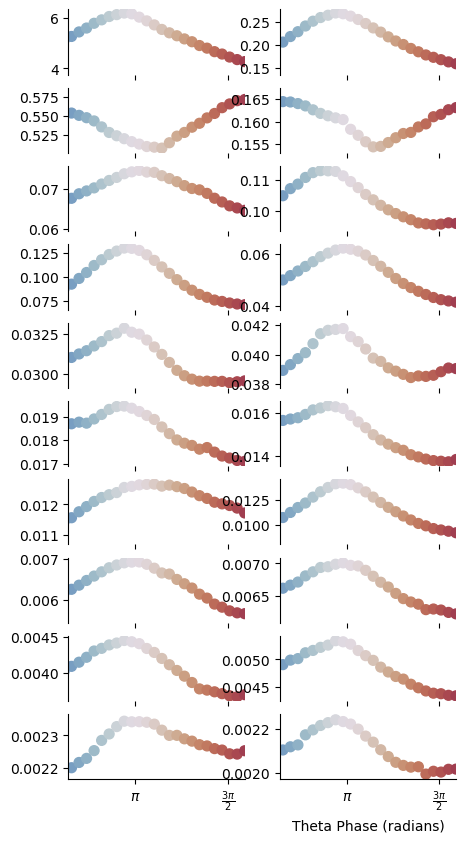

In [ ]:
if plotting == "median":
    mid = [np.nanmedian(b, axis=0) for b in binned_context]
    hi = [
        np.nanpercentile(
            b,
            75,
            axis=0,
        )
        for b in binned_context
    ]
    lo = [
        np.nanpercentile(
            b,
            25,
            axis=0,
        )
        for b in binned_context
    ]
elif plotting == "mean":
    mid = [np.nanmean(b, axis=0) for b in binned_context]
    hi = [
        np.nanmean(b, axis=0) + np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]
    lo = [
        np.nanmean(b, axis=0) - np.nanstd(b, axis=0) / np.sqrt(b.shape[0])
        for b in binned_context
    ]

mid = np.array(mid)
lo = np.array(lo)
hi = np.array(hi)
fig, ax = plt.subplots(
    nrows=min(context_dim, 10), ncols=2, figsize=(5, 10), sharex=True
)
c = [plt.cm.twilight_shifted(phase / (2 * np.pi)) for phase in bins[1:]]
for i, a in enumerate(np.ravel(ax)):
    a.scatter(bins[1:], mid[:, i], s=50, c=c)
    a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, color=c)
    a.spines[["top", "right", "bottom"]].set_visible(False)

for a in ax[-1, :]:
    a.spines["bottom"].set_visible(True)

plt.xlabel("Theta Phase (radians)")
plt.xticks(
    np.linspace(0, 2 * np.pi, 5),
    ["0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"],
)
plt.xlim(2, 5)
# ax[0].set_title(theta_key["filter_name"])

In [306]:
# p = interval_list_contains(test_intervals, all_poke_intervals[:, 0])
from src.c3po.analysis.analysis import interval_list_contains

marks = all_poke_intervals[:, 0]
reward_intervals = trial_df[trial_df.reward == 1][["t_poke", "t_out"]].values
unrewarded_intervals = trial_df[trial_df.reward == 0][["t_poke", "t_out"]].values

window = (-0.1, 0.1)
response = analysis.alligned_response(
    interval_list_contains(reward_intervals, marks), t_plot=window, pca=True
)

neg_response = analysis.alligned_response(
    interval_list_contains(unrewarded_intervals, marks), t_plot=window, pca=True
)

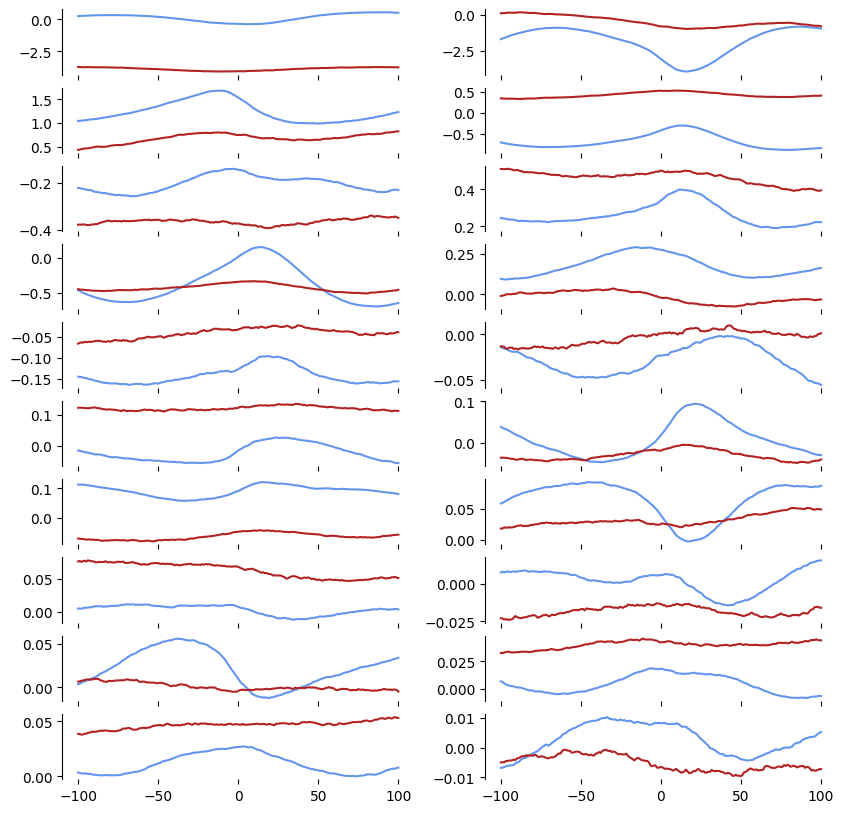

In [307]:
fig, ax = plt.subplots(
    nrows=analysis.context_dim // 2, ncols=2, sharex=True, figsize=(10, 10)
)
ax = np.ravel(ax)
color = "cornflowerblue"
t_plot = np.linspace(*window, response.shape[1]) * 1000
for i, a in enumerate(ax):
    data_i = response[..., i]
    yy = data_i.mean(axis=0)
    a.plot(t_plot, yy, color=color)

    data_i = neg_response[..., i]
    yy = data_i.mean(axis=0)
    a.plot(t_plot, yy, color="firebrick")

    a.spines[["top", "right", "bottom"]].set_visible(False)

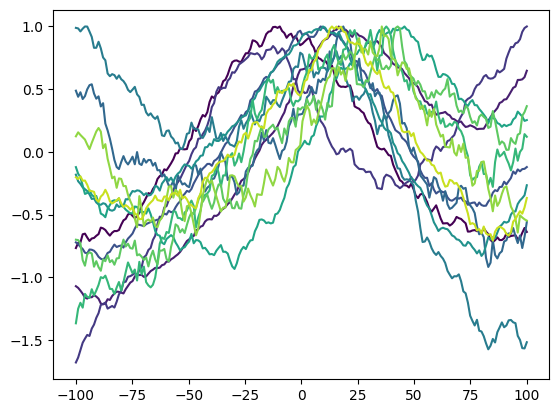

In [308]:
ind_ref = int(t_plot.size * 0.6)

n_plot = 12
for i in range(n_plot):
    color = plt.cm.viridis(i / n_plot)
    yy = neg_response[..., i].mean(axis=0)
    flip = ((yy[ind_ref] > np.mean(yy)) - 0.5) * 2

    yy = yy * flip
    yy = yy - np.mean(yy)
    yy = yy / np.max(yy)
    plt.plot(t_plot, yy, color=color)

# plt.xlim(-10,40)

## Spiking response to context phase

In [55]:
from src.c3po.analysis.analysis import (
    interval_list_contains,
    interval_list_contains_ind,
)

s = spikes[0]
bins = np.linspace(0, 2 * np.pi, 100)
# center = np.array(t_out)[all_behav["reward"].values == 1][:]
window = (0, 0.5)

# center = np.array(t_poke)[all_behav["reward"].values == 1]
# window = (.2,.5)

t_data = phase_df.index
data = phase_df.values

# center  = trial_df.t_poke.values
# test_intervals = np.array([(c + window[0], c + window[1]) for c in center])
# test_intervals = test_intervals[trial_df["reward"].values == 1]

# ceter = l_df.t_poke.values
# test_intervals = np.array([(c + window[0], c + window[1]) for c in center])
# test_intervals = test_intervals[trial_df["reward"].values == 1]

# test_intervals = np.array(
#     [trial_df["t_poke"].values[:-1], trial_df["t_out"].values[:-1]]
# ).T

_df = trial_df[trial_df["reward"] == 1]
# t_list = _df.t_poke.values
# test_intervals = np.array([[t+.5, t + 1.5] for t in t_list])
# t_list = _df.t_out.values
# test_intervals = np.array([[t + -2, t + -.5] for t in t_list])
test_intervals = _df[["t_poke", "t_out"]].values
test_intervals[:, 0] = test_intervals[:, 0] + 0.5

# test_intervals = np.array(
#     [[t-1,t] for t in trial_df["t_out"].values[:-1]]
# )


# test_intervals = [
#     t for i, t in enumerate(test_intervals) if trial_df["reward"].values[i] == 1
# ]
# test_intervals = [t for t in test_intervals if t[1] - t[0] > 0 and t[1] - t[0] < 60]
test_intervals = np.array(test_intervals)

# test_intervals = np.array([t_poke, t_out]).T
# test_intervals = test_intervals[all_behav["reward"].values == 0]


ind_data = interval_list_contains_ind(test_intervals, t_data)
counts = np.array(
    [np.histogram(data[ind_data, i], bins=bins)[0] for i in range(data.shape[1])]
).T
phase_densities = []
for s_full in spikes:
    s = interval_list_contains(test_intervals, np.array(s_full))
    # if len(s) < 100:
    #     continue

    data_s = data[np.digitize(s, t_data), :]
    h = np.array(
        [np.histogram(data_s[:, i_c], bins=bins)[0] for i_c in range(data.shape[1])]
    ).T
    # h = h / h.sum(axis=0)
    h = h / counts
    phase_densities.append(h)
phase_densities = np.array(phase_densities)

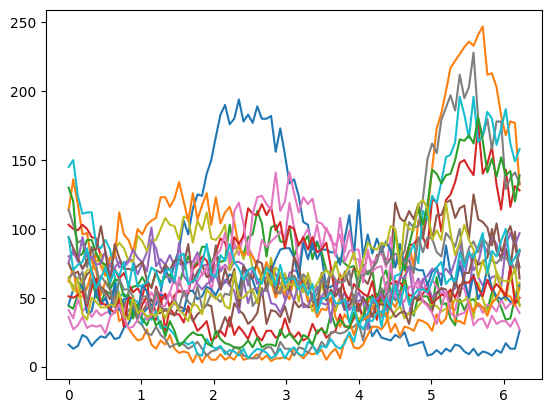

In [56]:
all_poke_intervals[:, 0]
p = interval_list_contains(test_intervals, all_poke_intervals[:, 0])

data_p = data[np.digitize(p, t_data), :]
h = np.array(
    [np.histogram(data_p[:, i_c], bins=bins)[0] for i_c in range(data.shape[1])]
).T
# h = h / h.sum(axis=0)
poke_density = h / counts


plt.plot(bins[:-1], h)

In [57]:
from spyglass.common import interval_list_contains_ind

# ind_data = interval_list_contains_ind(test_intervals, t_data)

counts = np.array(
    [np.histogram(data[ind_data, 0], bins=bins)[0] for i in range(data.shape[1])]
).T
h.shape, counts.shape
c_i = counts[:, i]
c_i = c_i / np.sum(c_i)
plt.plot(c_i)

IndexError: index 31 is out of bounds for axis 1 with size 20

In [94]:
# p = interval_list_contains(test_intervals, run_ripp_df["start_time"].values)
# i_c = 0
# data_p = data[np.digitize(p, t_data), :]
# h = np.array(
#     [np.histogram(data_p[:, i_c], bins=bins)[0] for i_c in range(data.shape[1])]
# ).T
# # h = h / h.sum(axis=0)
# ripple_density = h / counts


# plt.plot(bins[:-1], h[:, 0])

In [58]:
def smooth(x, window_len=11, window="hamming"):
    if x.ndim != 1:
        raise ValueError("smooth only accepts 1 dimension arrays.")
    if x.size < window_len:
        raise ValueError("Input vector needs to be bigger than window size.")
    if window_len < 3:
        return x
    if window == "hanning":
        w = np.hanning(window_len)
    elif window == "hamming":
        w = np.hamming(window_len)
    elif window == "blackman":
        w = np.blackman(window_len)
    elif window == "gaussian":
        w = np.hanning(window_len)
        w = np.exp(
            -0.5
            * (np.arange(window_len) - window_len // 2) ** 2
            / (window_len // 6) ** 2
        )
        w /= w.sum()
    else:
        raise ValueError("Window is on of 'hanning', 'hamming', 'blackman'")
    y = np.convolve(w / w.sum(), x, mode="valid")
    return y

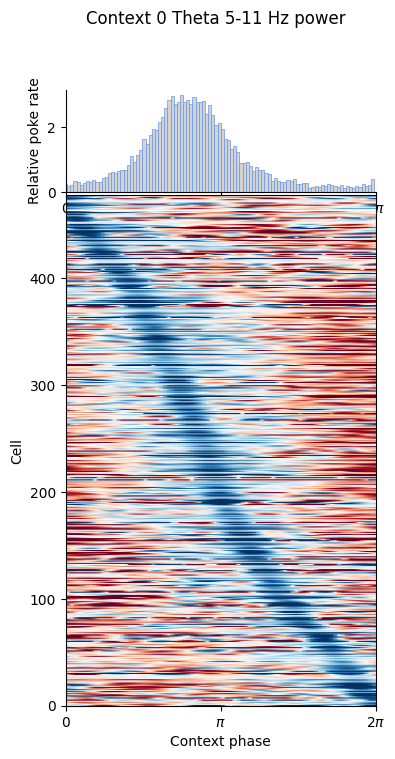

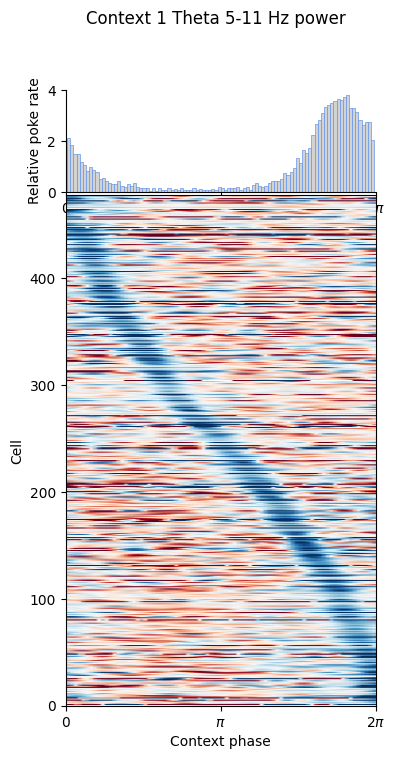

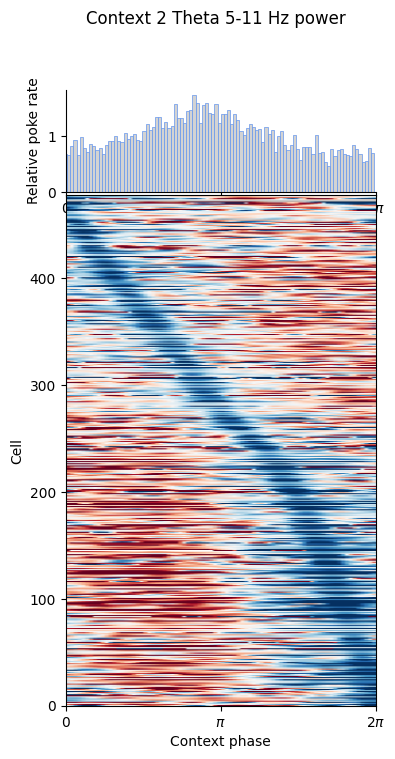

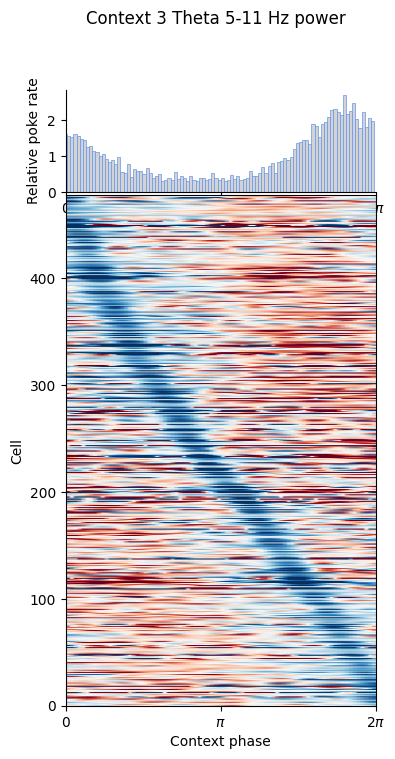

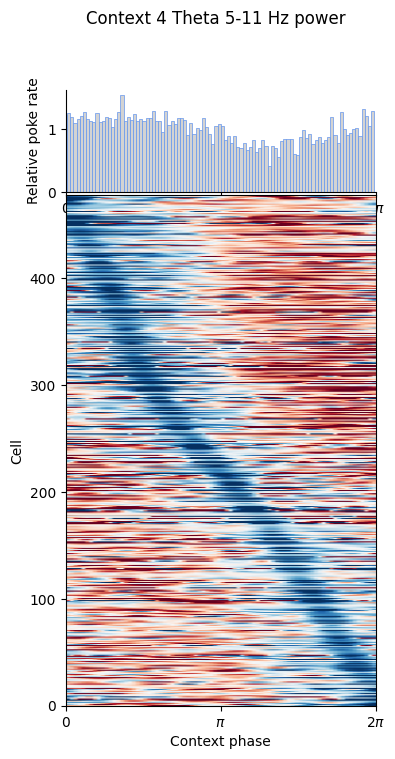

...

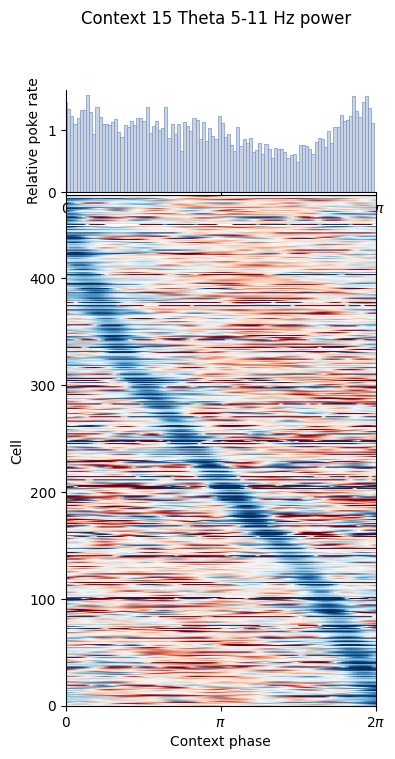

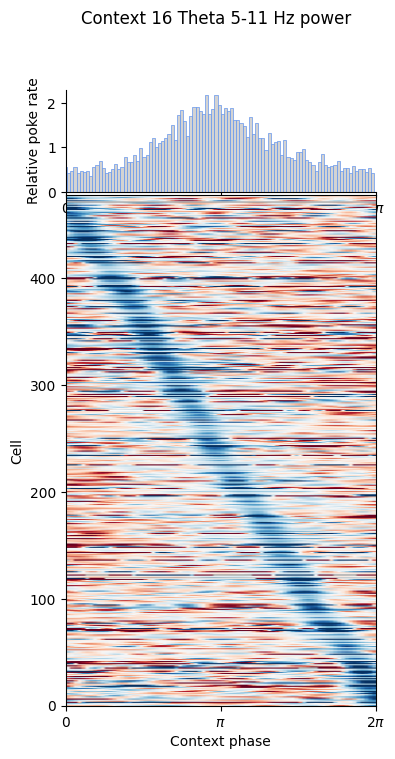

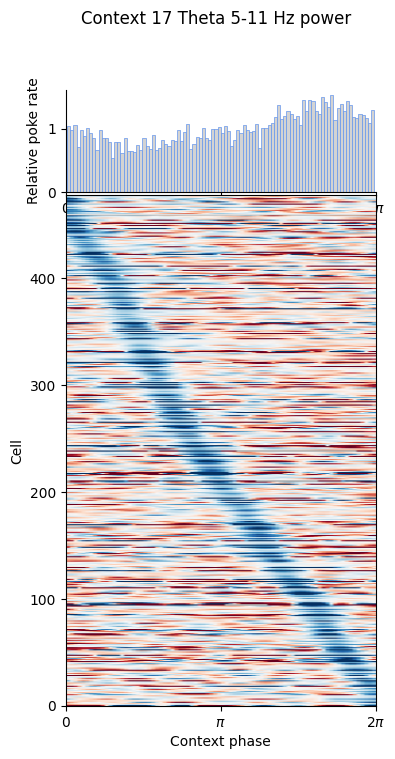

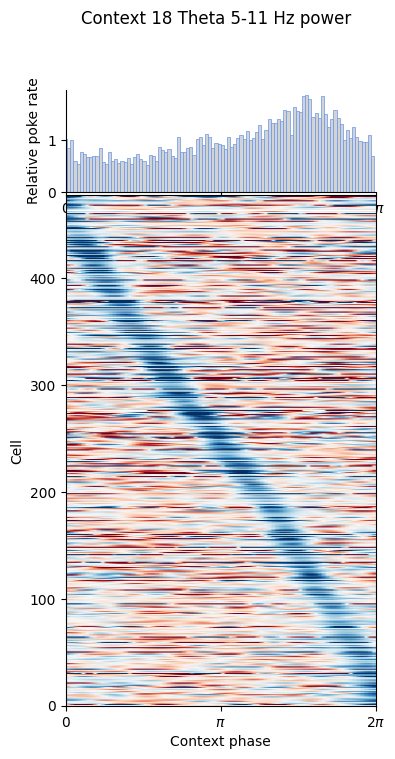

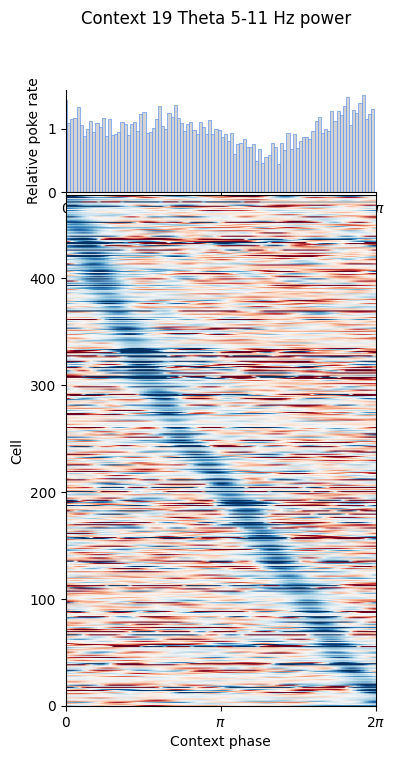

In [ ]:
# fig,ax = plt.subplots(nrows=2,sharex=True,height_ratios=[1,10])
import matplotlib.gridspec as gridspec

context_dim_list = list(range(phase_densities.shape[2]))

for context_dim in context_dim_list:
    fig = plt.figure(figsize=(4, 8))  # Adjust figure size if needed
    gs = gridspec.GridSpec(2, 1, height_ratios=[2, 10], hspace=0.01)
    ax0 = plt.subplot(gs[0])
    ax1 = plt.subplot(gs[1], sharex=ax0)

    poke_val = poke_density[:, context_dim]
    poke_val = poke_val / np.mean(poke_val)
    # poke_val = np.log2(poke_val)
    ax0.bar(
        bins[:-1],
        poke_val,
        facecolor="lightgrey",
        edgecolor="cornflowerblue",
        lw=0.5,
        width=np.diff(bins)[0],
    )
    ax0.set_xticks(
        [],
    )
    ax0.spines[
        [
            "top",
            "right",
        ]
    ].set_visible(False)
    ax0.set_ylabel("Relative poke rate")

    vals = phase_densities[:, :, context_dim]
    vals = np.array(
        [
            smooth(
                vals[i, :],
                20,
                window="gaussian",
                # sigma=3,
            )
            for i in range(vals.shape[0])
        ]
    )

    vals = vals / np.mean(vals, axis=1)[:, None]
    # vals = vals / np.max(vals, axis=1)[:, None]

    # vals = vals-(1/vals.shape[1])
    # vals = vals / (1 / vals.shape[1])
    # vals = np.concatenate([vals, vals], axis=1)

    vals = np.log2(vals)
    #
    ind_sort = np.argsort(np.argmax(vals, axis=1))

    c_scale = 0.2
    ax1.imshow(
        vals[ind_sort],
        aspect="auto",
        cmap="RdBu",
        clim=(-c_scale, c_scale),
        # clim = None,
        extent=[bins[0], bins[-1], 0, vals.shape[0]],
    )
    ax1.set_xticks([0, np.pi, 2 * np.pi], ["0", "$\pi$", "$2\pi$"])

    ax1.set_xlabel("Context phase")
    ax1.set_ylabel("Cell")
    fig.suptitle(f"Context {context_dim} {filter_name} power")
# plt.colorbar()
# plt.title("log2 firing rate/mean firing rate")

In [131]:
vals.shape

(478, 99)

NameError: name 'phase_densities' is not defined

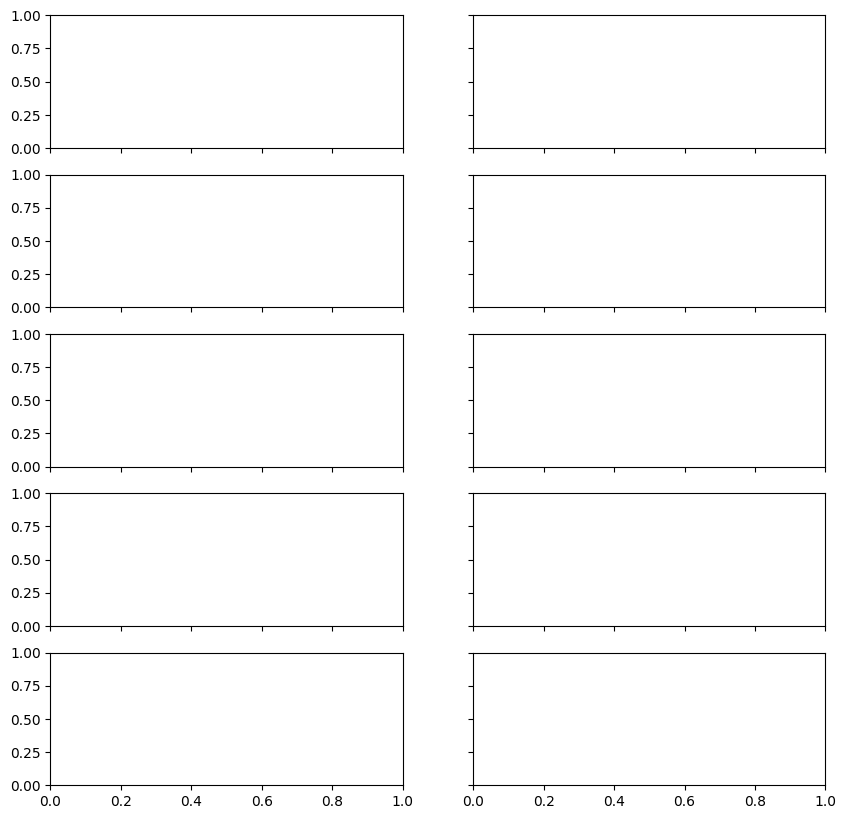

In [22]:
fig, ax = plt.subplots(5, 2, figsize=(10, 10), sharex=True, sharey=True)

for i, a in enumerate(ax.flatten()):
    vals = phase_densities[:, :, i]
    vals = vals / np.mean(vals, axis=1)[:, None]
    # vals = vals-(1/vals.shape[1])
    # vals = vals / (1 / vals.shape[1])
    vals = np.array(
        [
            smooth(
                vals[i, :],
                10,
            )
            for i in range(vals.shape[0])
        ]
    )

    vals = np.log2(vals)

    # ind_sort = np.argsort(np.argmax(vals, axis=1))

    c_scale = 0.2
    a.imshow(
        vals[ind_sort],
        aspect="auto",
        cmap="RdBu",
        clim=(-c_scale, c_scale),
        extent=[bins[0], bins[-1], 0, vals.shape[0]],
    )

# plt.xlabel("Context phase")
# plt.ylabel("Cell")
# plt.colorbar()
# plt.title("log2 firing rate/mean firing rate")

# Cross Correlograms


In [ ]:
# Intervals

# rewarded_lick_intervals
reward_trials_df = trial_df[trial_df["reward"] == 1]
rewarded_lick_intervals = np.array(
    [
        [max(row["t_poke"] + 0, row["t_out"] - 2), row["t_out"]]
        for _, row in reward_trials_df.iterrows()
    ]
)

In [302]:
lags, xcorr = analysis.cross_correlation(
    pca=True,
    intervals=rewarded_lick_intervals,
    processes=18,
    dim_limit=6,
    max_lag_seconds=0.5,
)

100%|██████████| 36/36 [01:02<00:00,  1.74s/it]


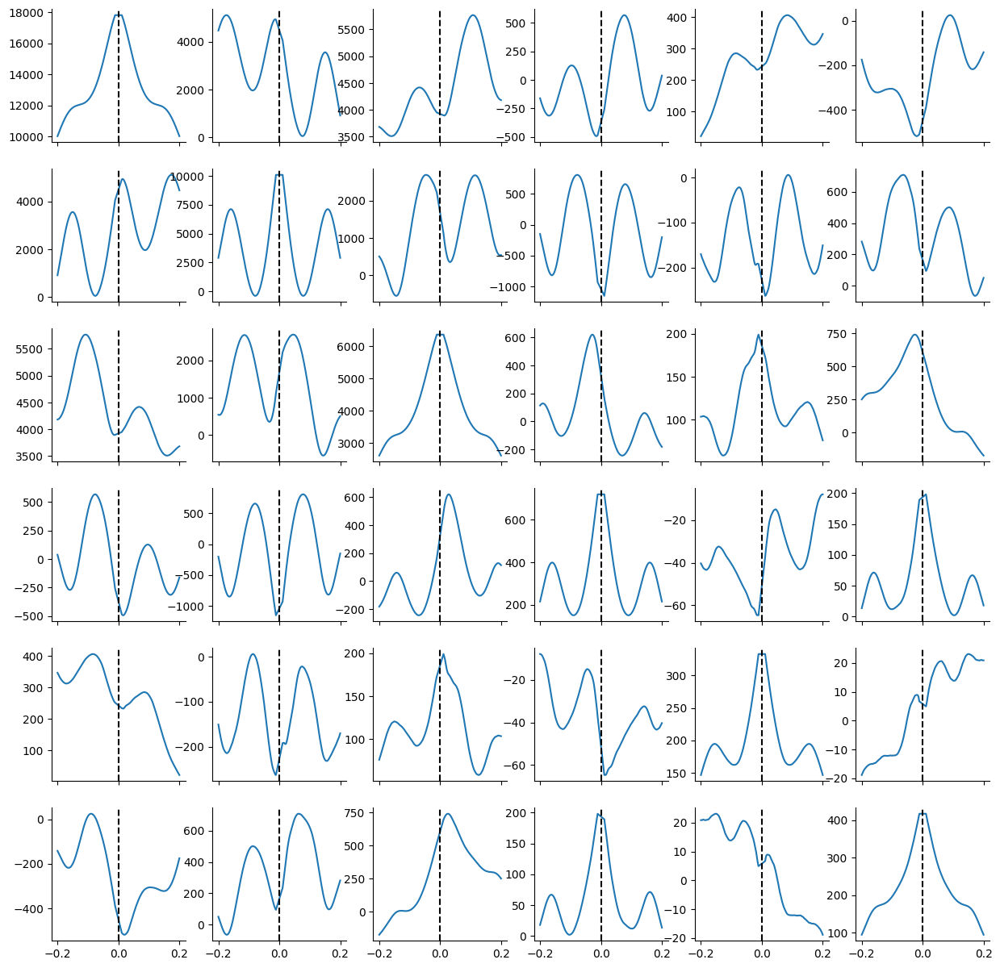

In [303]:
n = 6

tlim = 0.2
# tlim = 0.02, 0.2


if not isinstance(tlim, tuple):
    tlim = (-tlim, tlim)


import matplotlib.pyplot as plt

fig, ax = plt.subplots(n, n, figsize=(15, 15), sharex=True)
ind = np.where((lags > tlim[0]) & (lags < tlim[1]) & (np.abs(lags) > 0.01))[0]
for i in range(n):
    for j in range(n):
        ax[i, j].plot(lags[ind], xcorr[i, j, ind])

for a in ax.flatten():
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.axvline(0, color="k", linestyle="--")

# Lick response curves

In [304]:
poke_in_times = np.array(all_poke_intervals[:, 0])
window = -0.1, 0.5
response = analysis.alligned_response(poke_in_times, window, pca=True)

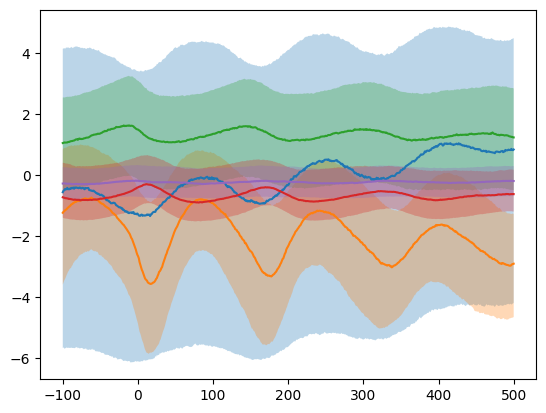

In [305]:
mid = np.median(response, axis=0)
lo = np.percentile(response, 25, axis=0)
hi = np.percentile(response, 75, axis=0)

t_plot = np.linspace(window[0], window[1], response.shape[1]) * 1000
for i in range(5):
    plt.fill_between(
        t_plot,
        lo[:, i],
        hi[:, i],
        alpha=0.3,
    )
    plt.plot(t_plot, mid[:, i])

In [ ]:
reward_trial_inds = np.where(trial_df["reward"].values == 1)[0]
reward_interval_starts = trial_df["t_poke"].values[reward_trial_inds]
reward_interval_ends = trial_df["t_out"].values[reward_trial_inds + 1]
reward_intervals = np.array(list(zip(reward_interval_starts, reward_interval_ends)))
reward_intervals.shape

unrewarded_trial_inds = np.where(trial_df["reward"].values == 0)[0][:-1]
unrewarded_interval_starts = trial_df["t_poke"].values[unrewarded_trial_inds]
unrewarded_interval_ends = trial_df["t_out"].values[unrewarded_trial_inds + 1]
unrewarded_intervals = np.array(
    list(zip(unrewarded_interval_starts, unrewarded_interval_ends))
)
unrewarded_intervals.shape

(990, 2)

In [ ]:
rewarded_poke_times = interval_list_contains(reward_intervals, all_poke_intervals[:, 0])
unrewarded_poke_times = interval_list_contains(
    unrewarded_intervals, all_poke_intervals[:, 0]
)

[11:46:45][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: interval_list_contains
	Use Interval.contains instead
[11:46:46][WARNING] Spyglass: Found overlap(s). Use no_overlap flag to consolidate or not: [1.61755444e+09, 1.61755445e+09] [1.61755445e+09, 1.61755447e+09] [1.61755448e+09, 1.61755450e+09] [1.61755452e+09, 1.61755454e+09] [1.61755453e+09, 1.61755455e+09] [1.61755454e+09, 1.61755456e+09] [1.61755455e+09, 1.61755456e+09] [1.61755458e+09, 1.61755459e+09] [1.61755459e+09, 1.61755461e+09] [1.61755460e+09, 1.61755461e+09] [1.61755462e+09, 1.61755463e+09] [1.61755462e+09, 1.61755463e+09] [1.61755464e+09, 1.61755465e+09] [1.61755467e+09, 1.61755468e+09] [1.61755473e+09, 1.61755475e+09] [1.61755476e+09, 1.61755477e+09] [1.61755478e+09, 1.61755479e+09] [1.61755480e+09, 1.61755482e+09] [1.61755481e+09, 1.61755482e+09] [1.61755482e+09, 1.61755483e+09] [1.61755484e+09, 1.61755485e+09] [1.61755484e+09, 1.61755485e+09] [1.61755488e+09, 1.61755490e+09] [1.61755493e+09, 1.61755

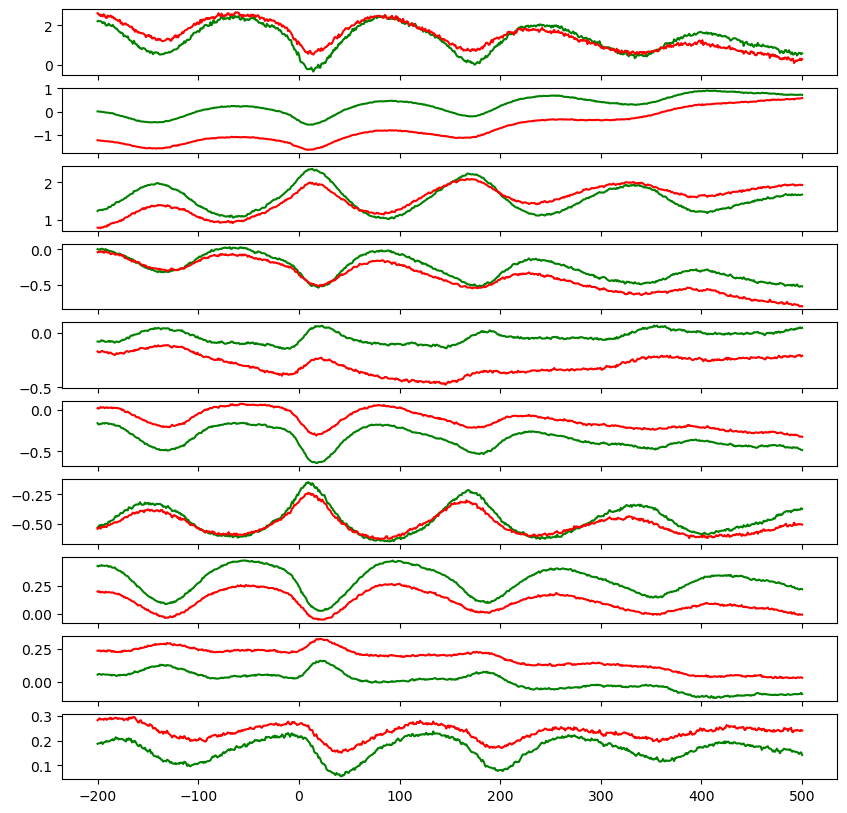

In [172]:
window = (-0.2, 0.5)
rewarded_response = analysis.alligned_response(rewarded_poke_times, window, pca=True)
unrewarded_response = analysis.alligned_response(
    unrewarded_poke_times, window, pca=True
)

t_plot = np.linspace(window[0], window[1], rewarded_response.shape[1]) * 1000
fig, ax = plt.subplots(
    10,
    figsize=(10, 10),
    sharex=True,
)
for i in range(ax.size):
    ax[i].plot(t_plot, rewarded_response[:, :, i].mean(axis=0), color="green")
    ax[i].plot(t_plot, unrewarded_response[:, :, i].mean(axis=0), color="red")

# Ripple Response curves

141


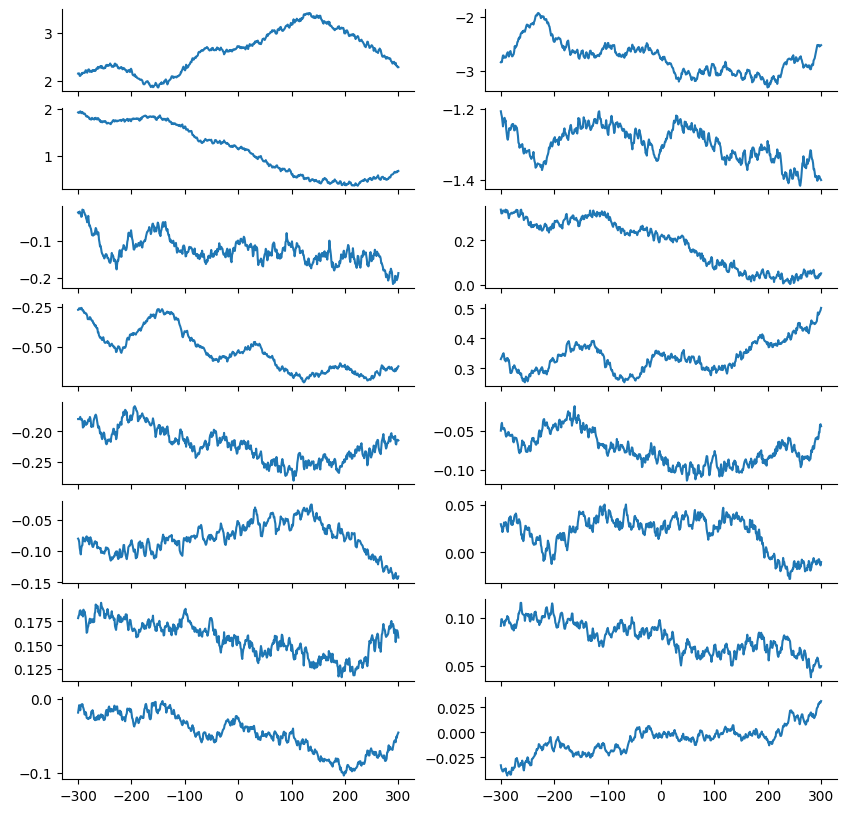

In [84]:
marks = run_ripp_df.start_time.values
len_ripple = run_ripp_df.end_time.values - run_ripp_df.start_time.values
marks = marks[len_ripple > 0.1]
print(marks.size)
window = -0.3, 0.3
response = analysis.alligned_response(marks, window, pca=True)

t_plot = np.linspace(window[0], window[1], response.shape[1]) * 1000
fig, ax = plt.subplots(8, 2, figsize=(10, 10), sharex=True)
ax = ax.flatten()
for i, a in enumerate(ax):
    a.plot(t_plot, response.mean(axis=0)[:, i])
    a.spines[["top", "right"]].set_visible(False)

# Power Spectrums

(0.0, 30.0)

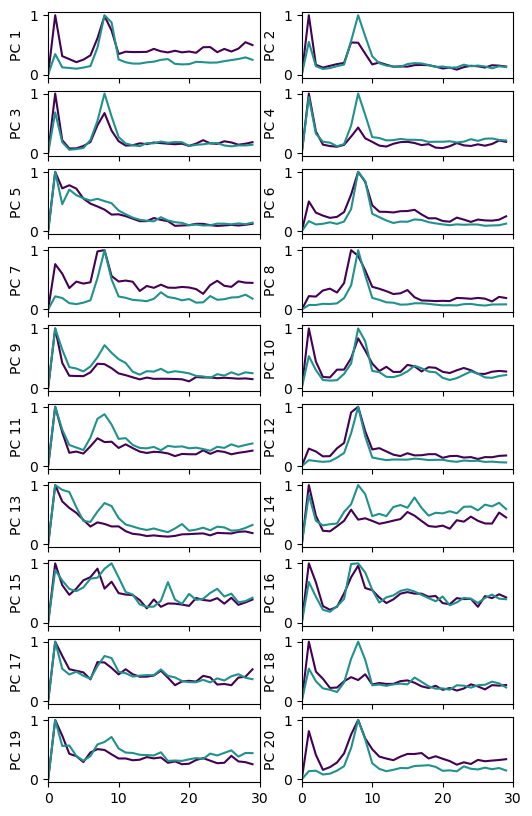

In [ ]:
bins = np.linspace(-15, 15, 30)
max_marks = None
nfft = 10000

max_marks = 100
nfft = 1000

# mark_feature = "t_choice"
# window = (-.3,-.1)

mark_feature = "run_start"
window = (0, 1)

mark_feature = "t_poke"
window = (0, 1)
# ------------------------

group_feature = "Q_trial"
feature_bins = np.linspace(0, 0.8, 10).round(2)
feature_bins = np.percentile(trial_df["Q_trial"].values, np.linspace(0, 100, 5)).round(
    2
)

group_feature = "Q_stem_trial"
feature_bins = np.linspace(0, 0.8, 8).round(2)
feature_bins = np.percentile(
    trial_df["Q_stem_trial"].values, np.linspace(10, 90, 6)
).round(2)

group_feature = "reward"
feature_bins = None

# ------------------------
exclude_feature = "n_pre_switch"
exclude_feature_values = [-1]


# ------------------------
if exclude_feature is None:
    exclude_mask = np.zeros(len(trial_df), dtype=bool)
else:
    val = trial_df[exclude_feature].values
    exclude_mask = np.isin(val, exclude_feature_values)

if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")
# ---


fig, ax_all = plt.subplots(
    min(10, analysis.context_dim // 2), ncols=2, figsize=(6, 10), sharex=True
)
ax = ax_all.flatten()

for i_cat, (inds, label) in enumerate(zip(category_inds, feature_labels)):
    if inds.sum() == 0:
        continue
    marks = trial_df[mark_feature].values[np.logical_and(inds, ~exclude_mask)]
    valid_intervals = []
    for t in marks[:max_marks]:
        valid_intervals.append([t + window[0], t + window[1]])

    f, mid, lo, hi = analysis.power_spectrum(
        intervals=valid_intervals,
        pca=True,
        window_size=int(1 / np.mean(np.diff(t_interp[:10]))),
        nfft=nfft,
    )
    ind_plot = f < 30
    f = f[ind_plot]
    mid = mid[:, ind_plot]
    norm_mid = mid.T * f[:, None]
    norm_mid = norm_mid / np.max(norm_mid, axis=0)
    color = plt.cm.viridis(i_cat / len(feature_labels))
    for i, a in enumerate(np.ravel(ax)):
        a.plot(f, norm_mid[:, i], label=label, color=color)
        a.set_ylabel(f"PC {i+1}")
    # break

plt.xlim(0, 30)

(0.0, 30.0)

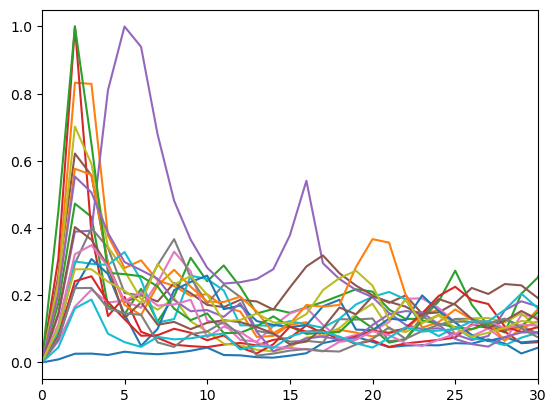

In [ ]:
norm_mid = mid.T * f[:, None]
norm_mid = norm_mid / np.max(norm_mid, axis=0)

plt.plot(f, norm_mid)
# plt.yscale('log')
plt.xlim(0, 30)

In [ ]:
for i, a in enumerate(np.ravel(ax)):
    a.plot(f, norm_mid[:, i], label=label)
    a.set_ylabel(f"PC {i+1}")

fig.show()

# Figurl



In [206]:
# trial_intervals = np.array([t_out[:n_trials], t_poke[1 : n_trials + 1]]).T
# trial_intervals = trial_intervals
# t_0 = trial_intervals[0][0] - 1
t_0 = trial_df.t_poke.values[5] - 1
plot_interval = np.array([[t_0, t_0 + 1000]])
ind_mark = interval_list_contains_ind(plot_interval, analysis.t)

ind_mark
c_temp = analysis.c[ind_mark]

In [207]:
stay_df = trial_df[trial_df.n_pre_switch > 0]
switch_df = trial_df[trial_df.n_pre_switch == 0]

stay_intervals = np.array(stay_df[["run_start", "t_poke"]].values)
ind = np.logical_and(
    stay_intervals[:, 0] > plot_interval[0, 0],
    stay_intervals[:, 0] < plot_interval[0, 1],
)
stay_intervals = stay_intervals[ind]

switch_intervals = np.array(switch_df[["run_start", "t_poke"]].values)
ind = np.logical_and(
    switch_intervals[:, 0] > plot_interval[0, 0],
    switch_intervals[:, 0] < plot_interval[0, 1],
)
switch_intervals = switch_intervals[ind]

In [208]:
from spyglass.utils.spikesorting import firing_rate_from_spike_indicator

time_mua = np.arange(np.min(plot_interval), np.max(plot_interval), 0.005)
min_time, max_time = time_mua[[0, -1]]
# spike_times = list([*times_list])
spike_indicator = np.zeros((len(time_mua), len(spikes)))

for ind, times in enumerate(spikes):
    times = times[np.logical_and(times >= min_time, times <= max_time)]
    spike_indicator[:, ind] = np.bincount(
        np.digitize(times, time_mua[1:-1]),
        minlength=time_mua.shape[0],
    )

if spike_indicator.ndim == 1:
    spike_indicator = spike_indicator[:, np.newaxis]

mua_plot = firing_rate_from_spike_indicator(spike_indicator, time_mua, multiunit=True)


# LFP
from spyglass.lfp.v1 import LFPV1

query = LFPV1() & {
    "nwb_file_name": "wilbur20210404_.nwb",
    "target_interval_list_name": "02_r1 noPrePostTrialTimes",
}

lfp_df = query.fetch1_dataframe()
t_lfp = lfp_df.index.values
# t_lfp = t_lfp - first_mark_time
ind_lfp = interval_list_contains_ind(plot_interval, t_lfp)

# Position
from spyglass.position.v1 import TrodesPosV1
from spyglass.common.common_position import IntervalPositionInfo

pos_key = {
    "nwb_file_name": "wilbur20210404_.nwb",
    "interval_list_name": "pos 1 valid times",
    "position_info_param_name": "default",
}
# TrodesPosV1 & key
pos_query = IntervalPositionInfo & pos_key
pos_df = pos_query.fetch1_dataframe()
t_pos = pos_df.index.values
# t_pos = t_pos - first_mark_time
ind_pos = interval_list_contains_ind(plot_interval, t_pos)
speed = pos_df.head_speed.values

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

In [209]:
import scipy.signal


def smooth(data, n=5, sigma=None, hamming=False, mode="valid"):
    """smooths data with gaussian kernel of size n"""
    if n % 2 == 0:
        n += 1  # make sure n is odd
    if sigma is None:
        sigma = n / 2
    kernel = gkern(n, sigma)[:, None]
    if hamming:
        n = sigma
        kernel = np.ones((sigma, 1)) / sigma
    if len(data.shape) == 1:
        pad = np.ones(((n - 1) // 2, 1))
        return np.squeeze(
            scipy.signal.convolve2d(
                np.concatenate(
                    [pad * data[:, None][0], data[:, None], pad * data[:, None][-1]],
                    axis=0,
                ),
                kernel,
                mode=mode,
            )
        )
    else:
        pad = np.ones(((n - 1) // 2, data.shape[1]))
        return scipy.signal.convolve2d(
            np.concatenate([pad * data[0], data, pad * data[-1]], axis=0),
            kernel,
            mode=mode,
        )


def gkern(l: int = 5, sig: float = 1.0):
    """
    creates gaussian kernel with side length `l` and a sigma of `sig`
    """
    ax = np.linspace(-(l - 1) / 2.0, (l - 1) / 2.0, l)
    gauss = np.exp(-0.5 * np.square(ax) / np.square(sig))
    return gauss / np.sum(gauss)
    kernel = np.outer(gauss, gauss)

In [210]:
import sortingview.views as vv

os.environ["KACHERY_API_KEY"] = "g9UmADRrAGfSPs1RRNKd6DtYTao3WQd2"
color_list = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

# CONTEXT
# subsample = 10
# context_graph = vv.TimeseriesGraph()
# c_fig = pca.transform(c[ind_mark])
# c_fig = smooth(c_fig, sigma=int(10), hamming=True)
# c_fig = c_fig[::subsample]
# for i in np.arange(
#     8,
# ):
#     context_graph.add_line_series(
#         name=f"context pc: {i}",
#         t=mark_times[ind_mark[::subsample]] / 1000,
#         y=c_fig[:, i].astype(np.float32),
#         width=2,
#         color=color_list[i],
#     )

subsample = 10
context_graph = vv.TimeseriesGraph()
c_fig = analysis.c_pca[ind_mark]
c_fig = smooth(c_fig, sigma=int(10), hamming=True)
c_fig = c_fig[::subsample]
t_fig = analysis.t

for i in np.arange(
    3,
):
    context_graph.add_line_series(
        name=f"context pc: {i}",
        t=t_fig[ind_mark[::subsample]],
        y=c_fig[:, i].astype(np.float32),
        width=2,
        color=color_list[i],
    )


context_graph2 = vv.TimeseriesGraph()
for i in np.arange(3, 7):
    context_graph2.add_line_series(
        name=f"context pc: {i}",
        t=t_fig[ind_mark[::subsample]],
        y=c_fig[:, i].astype(np.float32),
        width=2,
        color=color_list[i],
    )


# LFP
lfp_graph = vv.TimeseriesGraph()
lfp_graph.add_line_series(
    name="lfp",
    t=t_lfp[ind_lfp],
    y=lfp_df.iloc[ind_lfp][0].values,
    width=2,
    color="black",
)

# Speed
speed_graph = vv.TimeseriesGraph()
speed_graph.add_interval_series(
    name="stay trials",
    t_start=stay_intervals[:, 0],
    t_end=stay_intervals[:, 1],
    color="grey",
)
speed_graph.add_interval_series(
    name="switch trials",
    t_start=switch_intervals[:, 0],
    t_end=switch_intervals[:, 1],
    color="firebrick",
)

speed_graph.add_interval_series(
    name="poke_times",
    t_start=all_poke_intervals[:, 0],
    t_end=all_poke_intervals[:, 1],
    color="pink",
)

speed_graph.add_interval_series(
    name="reward_pump",
    t_start=all_pump_intervals[:, 0],
    t_end=all_pump_intervals[:, 1],
    color="cornflowerblue",
)

speed_graph.add_line_series(
    name="speed",
    t=t_pos[ind_pos],
    y=speed[ind_pos].astype(np.float32),
    width=2,
    color="teal",
)

# MUA
mua_graph = vv.TimeseriesGraph()
mua_graph.add_line_series(
    name="mua",
    t=time_mua,
    y=mua_plot.astype(np.float32),
    width=2,
    color="k",
)

# ASSEMBLE
context_panels = [
    vv.LayoutItem(speed_graph, stretch=1),
    vv.LayoutItem(lfp_graph, stretch=1),
    vv.LayoutItem(mua_graph, stretch=1),
    vv.LayoutItem(context_graph, stretch=3),
    vv.LayoutItem(context_graph2, stretch=3),
]

view = vv.Box(
    direction="horizontal",
    show_titles=True,
    height=8,
    items=[
        vv.LayoutItem(
            vv.Box(
                direction="vertical",
                show_titles=True,
                items=context_panels,
            )
        ),
    ],
)
view.url(label="test url")

'https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=kachery:franklab.default:sha1:049877694981009d735a746405041475d5f8c096&label=test%20url&zone=franklab.default'

In [211]:
model_name

'rat_mpfc_model202604_20dim_runEpochs_smooth'

array([[ 0.98686737,  0.89753318,  5.24561233, ...,  0.07424685,
        -0.02559466,  0.02549479],
       [ 1.78664724,  0.77773282,  5.01502666, ...,  0.05579737,
        -0.05569778,  0.01736457],
       [ 1.63327166,  0.82501802,  4.75432461, ...,  0.06342017,
        -0.01945311,  0.01538383],
       ...,
       [ 7.16556773,  5.93070504, -0.40982764, ..., -0.10592045,
         0.07404622,  0.18577984],
       [ 6.88614541,  5.41270568, -1.07274089, ..., -0.10191456,
         0.05183508,  0.1782853 ],
       [ 6.94176061,  5.35497432, -1.12211481, ..., -0.10124206,
         0.07019404,  0.18705326]])

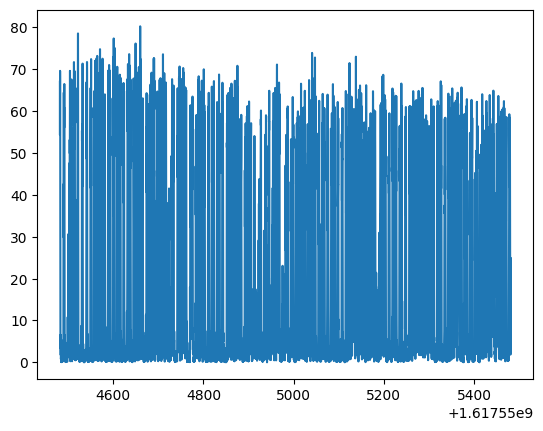

In [212]:
plt.plot(
    t_pos[ind_pos],
    speed[ind_pos].astype(np.float32),
)

c_fig

In [213]:
t_pos[ind_pos[:20]].astype(np.float32)

array([1.6175544e+09, 1.6175544e+09, 1.6175544e+09, 1.6175544e+09,
       1.6175544e+09, 1.6175544e+09, 1.6175544e+09, 1.6175544e+09,
       1.6175544e+09, 1.6175544e+09, 1.6175544e+09, 1.6175544e+09,
       1.6175544e+09, 1.6175544e+09, 1.6175544e+09, 1.6175544e+09,
       1.6175544e+09, 1.6175544e+09, 1.6175544e+09, 1.6175544e+09],
      dtype=float32)

# lick alligned spike response


In [ ]:
max_delay = 2

from spyglass.common.common_interval import Interval

reward_df = trial_df[trial_df["reward"] == 1]
reward_intervals = Interval(reward_df[["t_poke", "t_out"]].values)


marks = all_poke_intervals[:, 0]
marks = trial_df.t_poke.values + 0.001

marks = reward_intervals.contains(marks)

mark_intervals = Interval([[t_m - max_delay, t_m + max_delay] for t_m in marks])
mark_intervals = mark_intervals.consolidate()

In [223]:
min_spikes = 1000
from tqdm import tqdm
from multiprocessing import Pool


# corr_results = []
# for s in tqdm(spikes):

#     s = mark_intervals.contains(s)
#     if len(s) < min_spikes:
#         continue
#     delays = np.ravel(np.subtract.outer(marks, s))
#     bins = np.arange(-max_delay, max_delay,.002)

#     delays = delays[np.abs(delays)<max_delay]

#     y = np.histogram(delays, bins)[0]
#     corr_results.append(y)
#     # y = smooth(y,50)


def get_corr(
    s,
):
    s = mark_intervals.contains(s)
    if len(s) < min_spikes:
        return None
    delays = np.ravel(np.subtract.outer(marks, s))
    bins = np.arange(-max_delay, max_delay, 0.002)

    delays = delays[np.abs(delays) < max_delay]

    y = np.histogram(delays, bins)[0]
    return y


corr_results = []
with Pool(processes=64) as pool:
    for s in tqdm(spikes):
        # s = mark_intervals.contains(s)
        # if len(s) < min_spikes:
        #     continue
        corr_results.append(pool.apply_async(get_corr, args=(s,)))

    corr_results = [r.get() for r in tqdm(corr_results) if r is not None]

/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 478/478 [00:01<00:00, 254.78it/s]/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()



In [224]:
smoothed_corr = np.array([smooth(y, 15) for y in corr_results if y is not None])

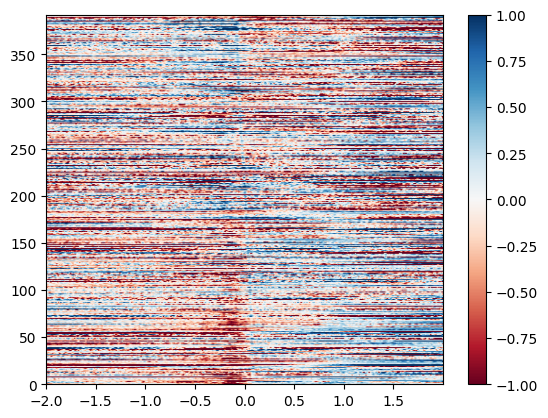

In [225]:
sort_on = np.arange(smoothed_corr.shape[1])
bins = np.arange(-max_delay, max_delay, 0.002)
sort_on = np.abs(bins[:-1]) < 0.08


ind_sort = np.argsort(np.argmax(smoothed_corr[:, sort_on], axis=1))
yy = smoothed_corr[ind_sort]
yy = yy / np.mean(yy, axis=1, keepdims=True)
yy = np.log2(yy)

clim = 1
plt.imshow(
    yy,
    aspect="auto",
    cmap="RdBu",
    clim=(-clim, clim),
    extent=[bins[0], bins[-1], 0, yy.shape[0]],
)
plt.colorbar()

## run marks

In [220]:
marks = trial_df.run_start.values
bins = np.arange(-0, 1, 0.01)

mark_intervals = Interval(
    [[t_m + bins[0], t_m + bins[-1]] for t_m in marks if ~np.isnan(t_m)]
).consolidate()


min_spikes = 1000
from tqdm import tqdm
from multiprocessing import Pool


def get_corr(s, mark_intervals):
    s = mark_intervals.contains(s)
    if len(s) < min_spikes:
        return None
    delays = np.ravel(np.subtract.outer(marks, s))

    delays = delays[np.logical_and(delays > bins[0], delays < bins[-1])]

    y = np.histogram(delays, bins)[0]
    return y


corr_results = []
with Pool(processes=64) as pool:
    for s in tqdm(spikes):
        # s = mark_intervals.contains(s)
        # if len(s) < min_spikes:
        #     continue
        corr_results.append(pool.apply_async(get_corr, args=(s, mark_intervals)))

    corr_results = [r.get() for r in tqdm(corr_results) if r is not None]

/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 478/478 [00:03<00:00, 121.99it/s]


In [221]:
corr_results

[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 

In [216]:
run_smoothed_corr = np.array([smooth(y, 5) for y in corr_results if y is not None])

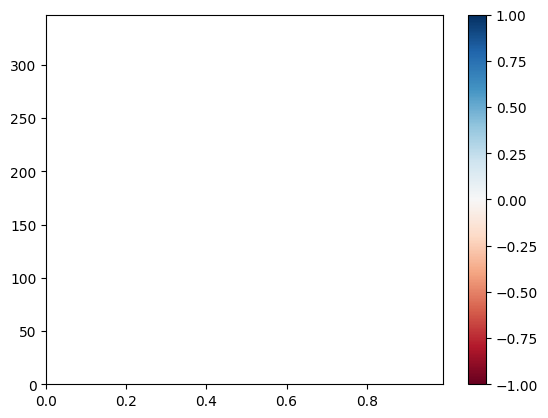

In [218]:
sort_on = np.arange(run_smoothed_corr.shape[1])
# bins = np.arange(-max_delay, max_delay, 0.002)
# sort_on = np.abs(bins[:-1]) < 0.08
# sort_on = bins[1:]>0

ind_sort = np.argsort(np.argmax(run_smoothed_corr[:, sort_on], axis=1))
yy = run_smoothed_corr[ind_sort]
yy = yy / np.mean(yy, axis=1, keepdims=True)
yy = np.log2(yy)

clim = 1
plt.imshow(
    yy,
    aspect="auto",
    cmap="RdBu",
    clim=(-clim, clim),
    extent=[bins[0], bins[-1], 0, yy.shape[0]],
)
plt.colorbar()

In [172]:
bins.size, run_smoothed_corr.shape

(350, (429, 349))